# <center> Importing Required Liabraries </center>

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings('ignore')

### Dataset Overview

This dataset comprises transaction records designed for analyzing and identifying possible fraudulent activities. It encompasses a range of attributes that shed light on transactional patterns, customer characteristics, and contextual information. These features make it ideal for implementing various anomaly detection and clustering methods to uncover irregularities and gain insights into transactional behaviors.

It contains **Bank Transaction Records** with 16 columns and 2512 entries.

Below is an overview about its features:

1. **TransactionID**: Unique identifier for each transaction.
2. **AccountID**: Unique identifier for the account involved in the transaction.
3. **TransactionAmount**: The monetary value of the transaction (in USD).
4. **TransactionDate**: Timestamp of when the transaction occurred.
5. **TransactionType**: Specifies whether the transaction was a **Debit** or **Credit**.
6. **Location**: City where the transaction took place.
7. **DeviceID**: Unique identifier for the device used for the transaction.
8. **IP Address**: The IP address of the device used for the transaction.
9. **MerchantID**: Unique identifier for the merchant involved in the transaction.
10. **Channel**: Indicates the transaction channel, e.g., **ATM** or **Online**.
11. **CustomerAge**: Age of the account holder.
12. **CustomerOccupation**: Occupation of the account holder, e.g., **Doctor**, **Student**.
13. **TransactionDuration**: Duration of the transaction in seconds.
14. **LoginAttempts**: Number of login attempts before completing the transaction.
15. **AccountBalance**: Account balance after the transaction (in USD).
16. **PreviousTransactionDate**: Date and time of the previous transaction for the same account.

# <center> Importing Dataset </center>

In [2]:
data=pd.read_csv(r"C:\Users\erpra\Documents\ExploratoryDataAnalysis\Bank Transaction Dataset for Fraud Detection\bank_transactions_data_2.csv")
data.head(15)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
5,TX000006,AC00393,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,18,Student,172,1,781.68,2024-11-04 08:06:36
6,TX000007,AC00199,7.08,2023-02-15 16:36:48,Credit,Seattle,D000241,140.212.253.222,M019,ATM,37,Doctor,139,1,13316.71,2024-11-04 08:10:09
7,TX000008,AC00069,171.42,2023-05-08 17:47:59,Credit,Indianapolis,D000500,92.214.76.157,M020,Branch,67,Retired,291,1,2796.24,2024-11-04 08:10:55
8,TX000009,AC00135,106.23,2023-03-21 16:59:46,Credit,Detroit,D000690,24.148.92.177,M035,Branch,51,Engineer,86,1,9095.14,2024-11-04 08:11:14
9,TX000010,AC00385,815.96,2023-03-31 16:06:57,Debit,Nashville,D000199,32.169.88.41,M007,ATM,55,Doctor,120,1,1021.88,2024-11-04 08:06:32


# <center> Getting Started with the Dataset </center>

In [3]:
print("The shape of the Dataset: ", data.shape)
print("\nDataset Information || Total Null Enteries || Total Duplicates\n")

data.info(), print("\nTotal Null Enteries: ", data.isna().sum().sum()), print("\nTotal Duplicates: ", data.duplicated().sum());

col_n = data.columns
print('\nSummary of unique enteries in each columns:\n')

for col in col_n:
    print(f"Total number of unique values for {col}: {data[col].nunique()}")

The shape of the Dataset:  (2512, 16)

Dataset Information || Total Null Enteries || Total Duplicates

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512

In [4]:
print("Statistical Summary:")
#exploring the unique values of each attribute
print("\n1-Number of Transactions: ", data['TransactionID'].nunique())
print("2-Number of Accounts: ",data['AccountID'].nunique())
print("3-Number of Merchants:", data['MerchantID'].nunique())
print("4-Total number of cities:", data['Location'].nunique())
print(f"5-Cutomers ages ranges from {data['CustomerAge'].min()} to {data['CustomerAge'].max()}")
print("6-Percentage of customers NA: ", round(data['AccountID'].isnull().sum() * 100 / len(data),2),"%" )
print("7-Average of 'Debit' & 'Credit' amount by a customer: ", round(data[data['TransactionType'] == 'Debit']['TransactionAmount'].\
                                                                    mean(),3), '& ', round(data[data['TransactionType'] == 'Credit']['TransactionAmount'].mean(),3))
txn_by_location = data.groupby('Location')['TransactionAmount'].sum().sort_values(ascending=False).reset_index()
print(f"8-Highest/Lowest Transaction Amount by Location: {txn_by_location['Location'][0]}:{txn_by_location['TransactionAmount'][0]}/{txn_by_location['Location'][42]}:{txn_by_location['TransactionAmount'][42]}")
print("9-Total transactions amount by 'Channels': \n\n", data.groupby('Channel')['TransactionAmount'].sum())
print("\n10-Total transaction amount by 'Occupations':\n\n", data.groupby('CustomerOccupation')['TransactionAmount'].sum())
print("\n11-Unique count of Devices: ", data['DeviceID'].nunique())
print("12-Unique count of 'IP Address': ", data['IP Address'].nunique(), "\n\n")
print("13-Numerical features summary:\n\n")
display(data.describe().T)

Statistical Summary:

1-Number of Transactions:  2512
2-Number of Accounts:  495
3-Number of Merchants: 100
4-Total number of cities: 43
5-Cutomers ages ranges from 18 to 80
6-Percentage of customers NA:  0.0 %
7-Average of 'Debit' & 'Credit' amount by a customer:  294.991 &  306.501
8-Highest/Lowest Transaction Amount by Location: Austin:22740.9/Albuquerque:10214.09
9-Total transactions amount by 'Channels': 

 Channel
ATM       256331.43
Branch    250183.00
Online    241041.14
Name: TransactionAmount, dtype: float64

10-Total transaction amount by 'Occupations':

 CustomerOccupation
Doctor      184693.81
Engineer    180650.06
Retired     176425.67
Student     205786.03
Name: TransactionAmount, dtype: float64

11-Unique count of Devices:  681
12-Unique count of 'IP Address':  592 


13-Numerical features summary:




,count,mean,std,min,25%,50%,75%,max
TransactionAmount,2512.0,297.593778,291.946243,0.26,81.885,211.14,414.5275,1919.11
CustomerAge,2512.0,44.673965,17.792198,18.00,27.000,45.00,59.0000,80.00
TransactionDuration,2512.0,119.643312,69.963757,10.00,63.000,112.50,161.0000,300.00
LoginAttempts,2512.0,1.124602,0.602662,1.00,1.000,1.00,1.0000,5.00
AccountBalance,2512.0,5114.302966,3900.942499,101.25,1504.370,4735.51,7678.8200,14977.99


In [5]:
# define numerical & categorical columns
numeric_features = [feature for feature in data.columns if data[feature].dtype != 'O']
categorical_features = [feature for feature in data.columns if data[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 5 numerical features : ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']

We have 11 categorical features : ['TransactionID', 'AccountID', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerOccupation', 'PreviousTransactionDate']


Unique Values for Categorical Columns:

* **TransactionID**: 2512 unique values (each transaction is unique).
* **TransactionType**: ['Debit', 'Credit']
* **Location**: 43 unique U.S. city names.
* **Channel**: ['ATM', 'Online', 'Branch']
* **CustomerOccupation**: ['Doctor', 'Student', 'Retired', 'Engineer']
* **AccountID**, **DeviceID**, **MerchantID**, **IP Address**, **TransactionDate**, **PreviousTransactionDate**: Each contains numerous distinct values representing specific IDs or time markers.

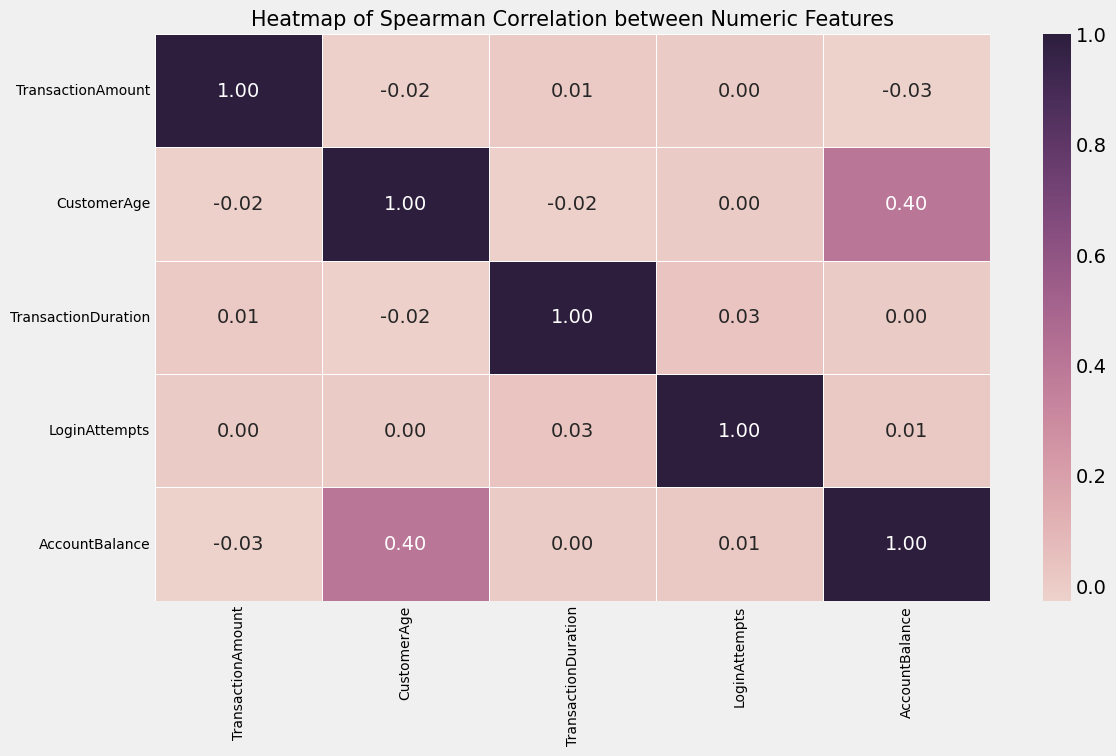

In [6]:
plt.figure(figsize=(12,7))
correlated_mat=data[numeric_features].corr(method='spearman')
sns.heatmap(correlated_mat,annot=True,fmt=".2f",cmap=sns.cubehelix_palette(as_cmap=True), linewidths=.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title("Heatmap of Spearman Correlation between Numeric Features", fontsize=15)
plt.show()

### Column-Wise Observations Based on Correlation Levels:

1. **TransactionAmount**:
   - Weak or negligible correlation with all other columns.
   - Correlation with:
     - CustomerAge: **-0.02**
     - TransactionDuration: **0.01**
     - LoginAttempts: **0.00**
     - AccountBalance: **-0.03**
   - **Observation**: TransactionAmount is mostly independent of other features.

2. **CustomerAge**:
   - Moderate positive correlation with **AccountBalance** (**0.40**).
   - Negligible or weak correlation with:
     - TransactionAmount: **-0.02**
     - TransactionDuration: **-0.02**
     - LoginAttempts: **0.00**
   - **Observation**: Older customers tend to have higher account balances, but their age does not significantly affect transaction behaviors.

3. **TransactionDuration**:
   - Weak or negligible correlation with all other columns.
   - Correlation with:
     - TransactionAmount: **0.01**
     - CustomerAge: **-0.02**
     - LoginAttempts: **0.03**
     - AccountBalance: **0.00**
   - **Observation**: TransactionDuration shows no significant linear relationship with other variables.

4. **LoginAttempts**:
   - Weak or negligible correlation with all other columns.
   - Correlation with:
     - TransactionAmount: **0.00**
     - CustomerAge: **0.00**
     - TransactionDuration: **0.03**
     - AccountBalance: **0.01**
   - **Observation**: LoginAttempts are independent of other transactional or demographic variables.

5. **AccountBalance**:
   - Moderate positive correlation with **CustomerAge** (**0.40**).
   - Negligible or weak correlation with:
     - TransactionAmount: **-0.03**
     - TransactionDuration: **0.00**
     - LoginAttempts: **0.01**
   - **Observation**: AccountBalance is influenced by CustomerAge but remains independent of transactional behaviors.

---

### Insights from the Heatmap of Spearman Correlation:

1. **Overall Weak Correlations**:
   - Most correlations are close to 0, indicating weak or negligible relationships between the variables.

2. **Significant Positive Correlation**:
   - **CustomerAge** and **AccountBalance** show a moderately positive correlation (0.40). This suggests that older customers tend to have higher account balances.

3. **Negligible Relationships**:
   - The correlations between **TransactionAmount**, **TransactionDuration**, **LoginAttempts**, and other variables are close to zero. These features are largely independent of each other.

4. **Uncorrelated Variables**:
   - Variables like **LoginAttempts** and **CustomerAge**, as well as **LoginAttempts** and **TransactionAmount**, have correlations of nearly zero, indicating no linear or monotonic relationship.

5. **Correlation of Key Features**:
   - **TransactionAmount** shows no meaningful correlation with any other variable, suggesting that the transaction amount operates independently within the dataset.

---

### Recommendations:
- The weak correlations suggest the need to explore non-linear relationships or segment data by categories for deeper insights.
- Since CustomerAge and AccountBalance show a moderately positive correlation, further investigation could reveal causal or behavioral trends between these features.

---

### Summary:
- **CustomerAge** and **AccountBalance** show a meaningful correlation (**0.40**), indicating a possible trend worth further exploration.
- Other features are mostly uncorrelated, suggesting independence or non-linear relationships that may require advanced techniques for detection.

# <center> Exploratory Data Analysis (EDA) </center>

In [7]:
data['Channel'].value_counts()

Channel
Branch    868
ATM       833
Online    811
Name: count, dtype: int64

In [8]:
location_txn_count=data['Location'].value_counts()

print("Total number of locations: ",data['Location'].nunique(),"\n")
print("Top 20 Locations: \n\n",location_txn_count[:20])

Total number of locations:  43 

Top 20 Locations: 

 Location
Fort Worth          70
Los Angeles         69
Oklahoma City       68
Charlotte           68
Tucson              67
Philadelphia        67
Omaha               65
Miami               64
Detroit             63
Houston             63
Memphis             63
Denver              62
Kansas City         61
Boston              61
Mesa                61
Atlanta             61
Seattle             61
Colorado Springs    60
Jacksonville        60
Fresno              60
Name: count, dtype: int64


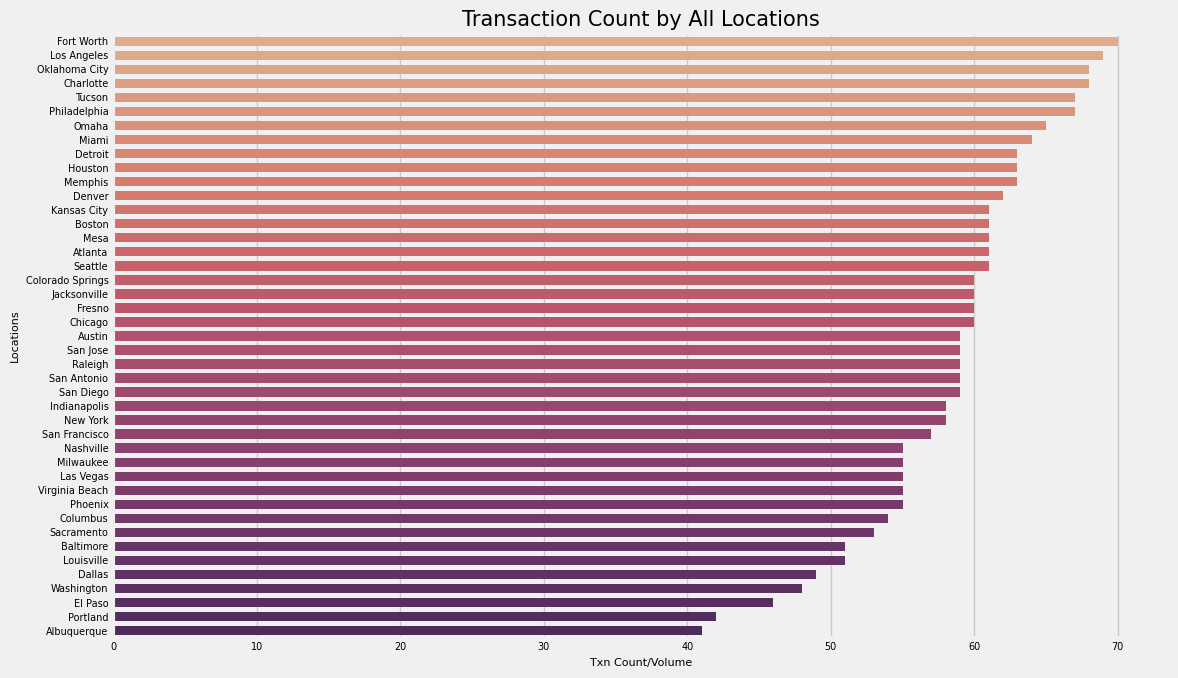

In [9]:
plt.figure(figsize=(12,7))

sns.barplot(y=location_txn_count.index, x=location_txn_count.values, palette="flare",width=0.67)
plt.title('Transaction Count by All Locations', fontsize=15)
plt.xlabel('Txn Count/Volume', fontsize=8)
plt.ylabel('Locations', fontsize=8)
plt.yticks(fontsize=7)
plt.xticks(fontsize=7)
plt.tight_layout()
plt.show()

1. HISTOGRAMS & DENSITY PLOTS:

- Histograms are similar to bar charts which display the counts or relative frequencies of values falling in different class intervals or ranges. A histogram displays the shape and spread of continuous sample data. It also helps us understand the skewness and kurtosis of the distribution of the data.

- A density plot is like a smoother version of a histogram.In density plots, we use the kernel density estimate to show the probability density function of the variable. The kernel, a continuous curve, is drawn to generate a smooth density estimation for the entire dataset.

2. SWARM PLOT:

- The swarm-plot, similar to a strip-plot, provides a visualization technique for univariate data to view the spread of values in a continuous variable. The only difference between the strip-plot and the swarm-plot is that the swarm-plot spreads out the data points of the variable automatically to avoid overlap and hence provides a better visual overview of the data.

3. VIOLIN PLOT :

- The Violin plot is very much similar to a box plot, with the addition of a rotated kernel density plot on each side. This display shows how quantitative data distribute across multiple levels of one (or more) categorical variables, allowing for comparisons between these distributions.

### 1 Univariate Analysis

#### 1.1 Numerical Variables
- **Columns:** `TransactionAmount` `CustomerAge` `TransactionDuration` `LoginAttempts` `AccountBalance`


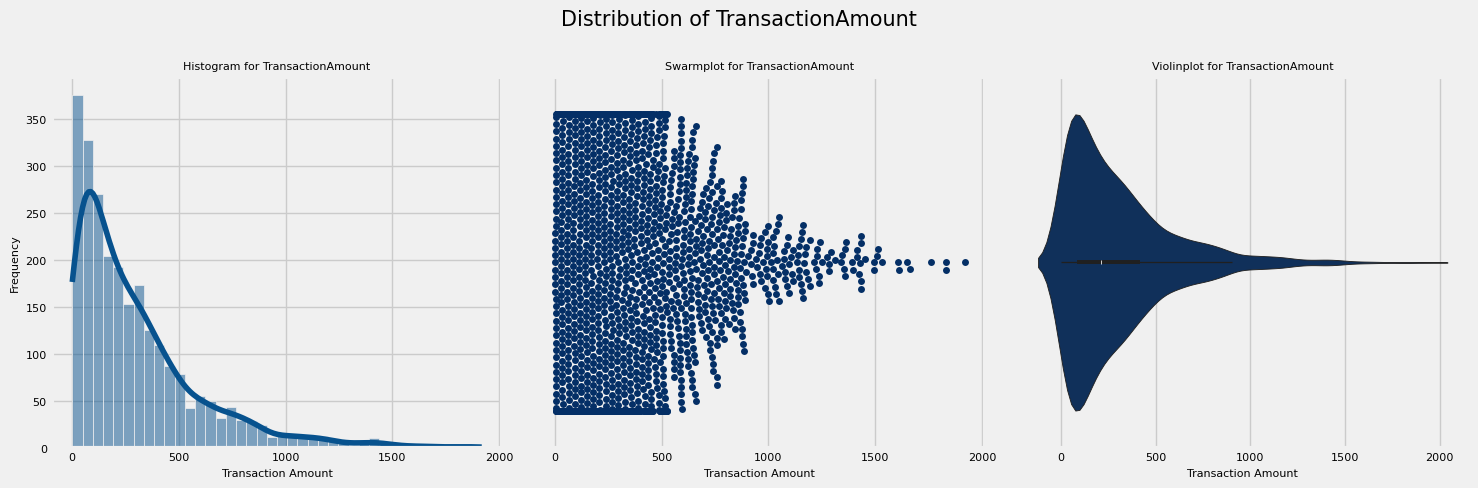

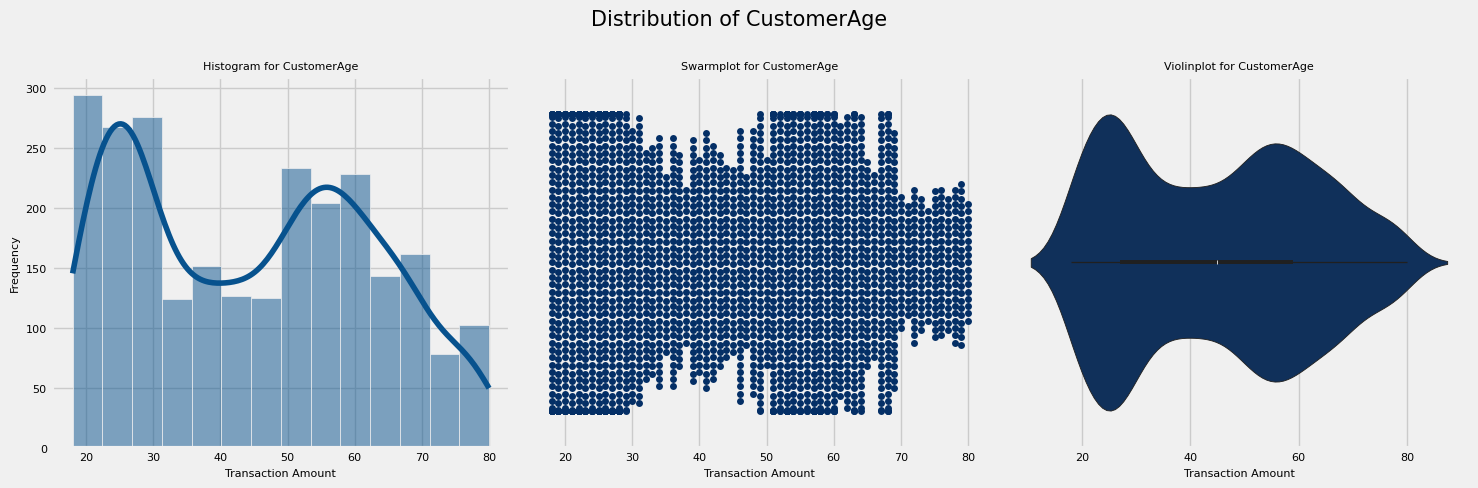

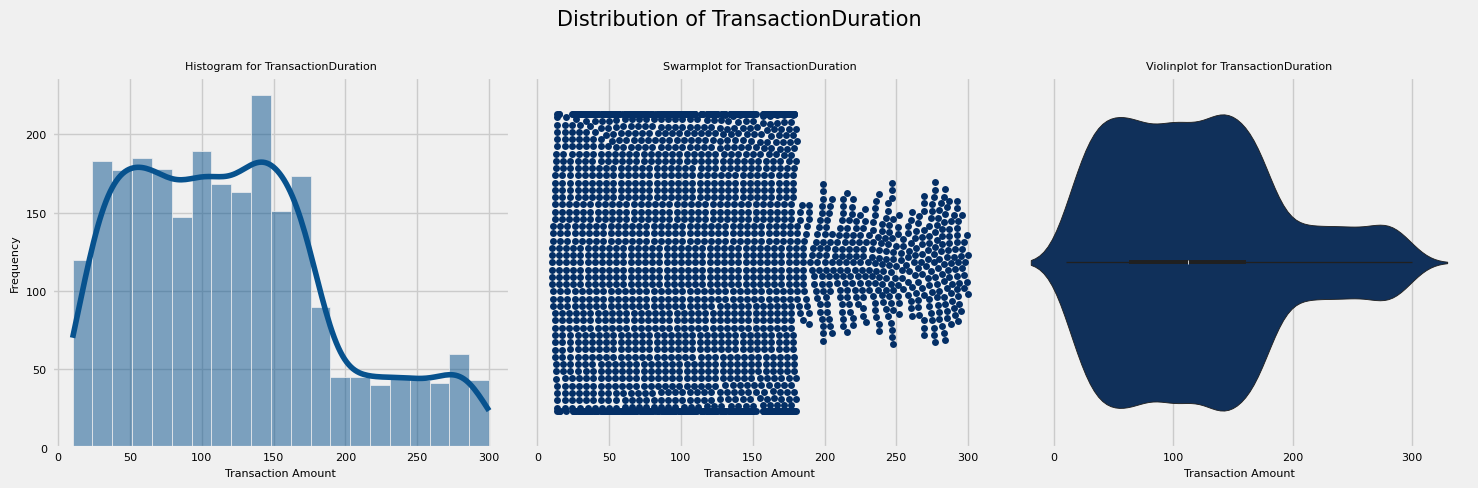

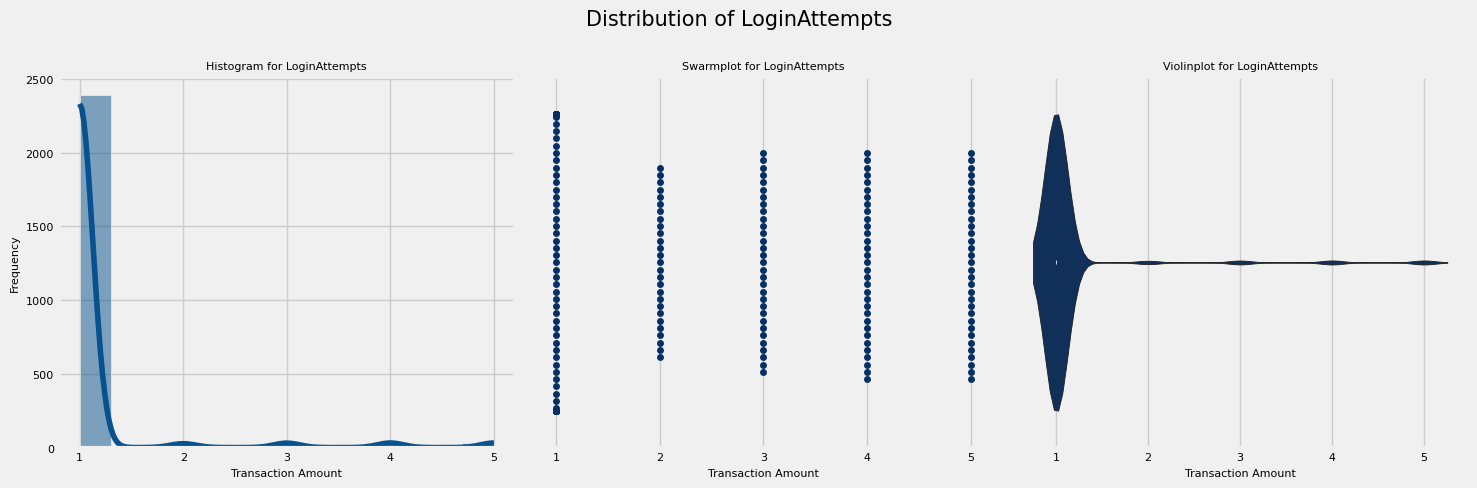

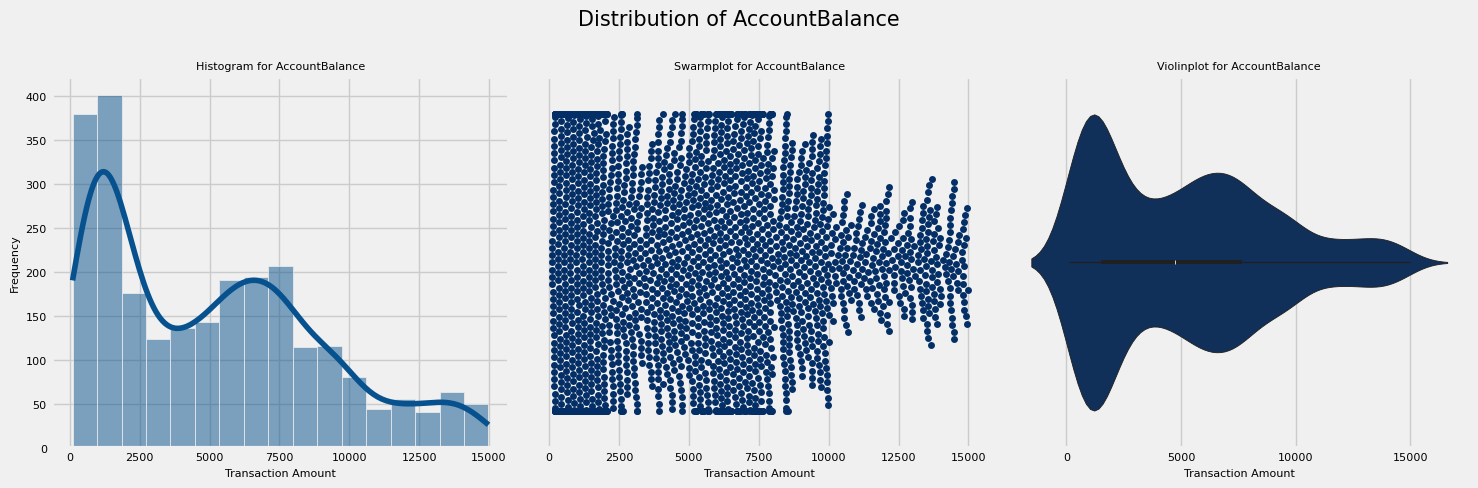

In [10]:
## Defining a function for Univariate Analysis for Numerical columns

def plot_distribution(data, col_name):

    for c in col_name:
        plt.figure(figsize=(15, 5))

        # Set the overall title
        plt.suptitle(f"Distribution of {c}", fontsize=15)

        # Histogram with KDE on the left
        plt.subplot(1, 3, 1)
        sns.histplot(data=data, x=c, kde=True, color="#07528e")
        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)
        plt.title(f"Histogram for {c}", fontsize=8)
        plt.xlabel("Transaction Amount", fontsize=8)
        plt.ylabel("Frequency", fontsize=8)

        # Creating a Boxplot
        plt.subplot(1, 3, 2)
        sns.swarmplot(x=data[c], color='#042f66')
        plt.xticks(fontsize=8)
        plt.title(f"Swarmplot for {c}", fontsize=8)
        plt.xlabel("Transaction Amount", fontsize=8)

        # Creating a Boxplot
        plt.subplot(1, 3, 3)
        sns.violinplot(x=data[c], color='#042f66')
        plt.title(f"Violinplot for {c}", fontsize=8)
        plt.xticks(fontsize=8)
        plt.xlabel("Transaction Amount", fontsize=8)

        # Adjust layout
        plt.tight_layout(rect=[0, 0, 1, 1])  # Leave space for suptitle
        plt.show()

        

plot_distribution(data, numeric_features)

#### 1.2 Categorical Variables
- **Columns:** `TransactionType` `Location` `DeviceID` `IP Address` `MerchantID` `Channel` `CustomerOccupation`

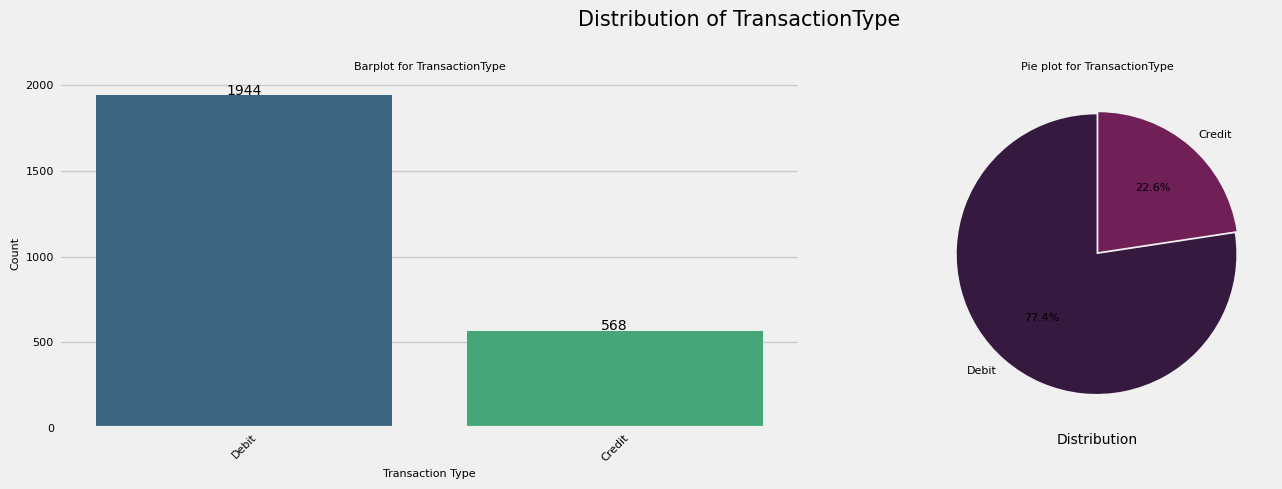

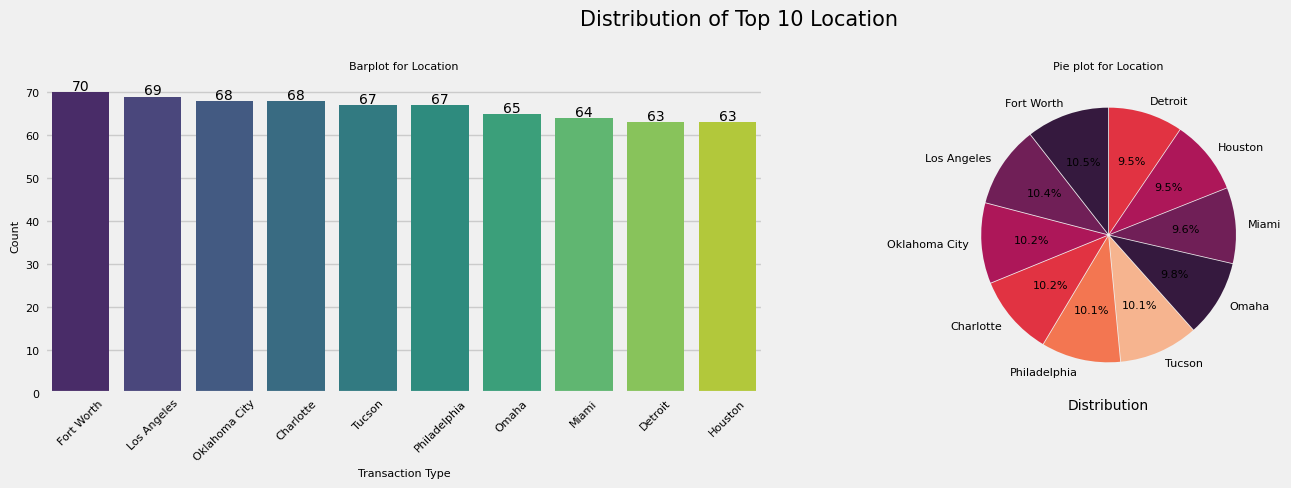

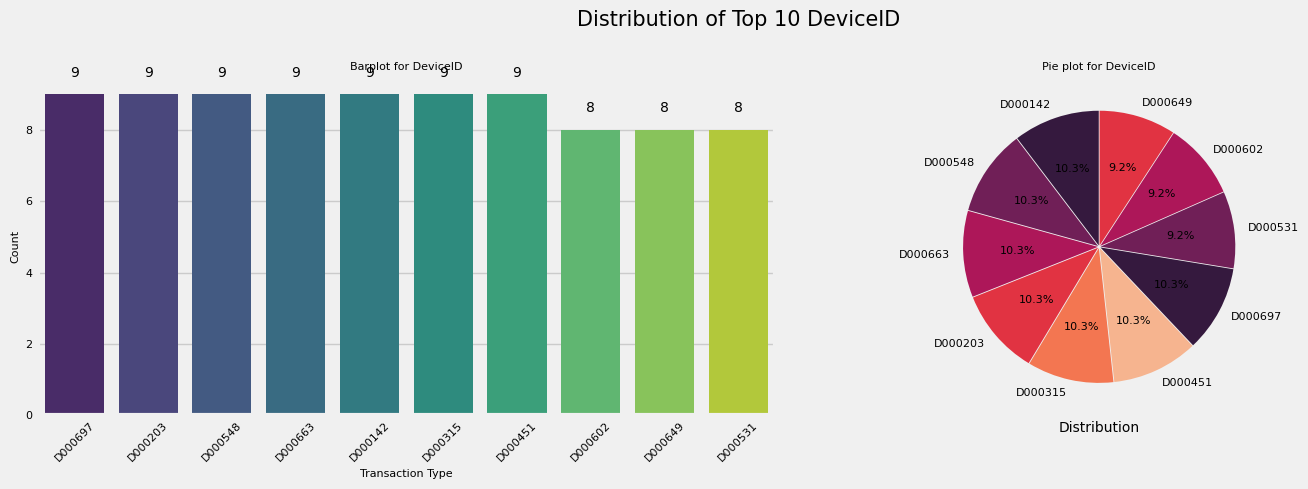

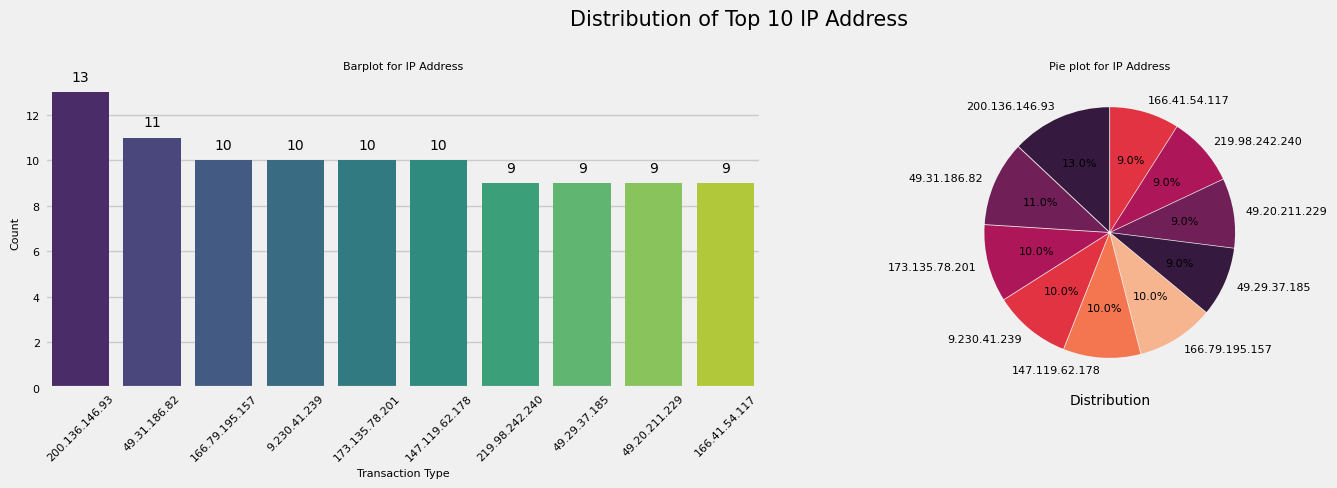

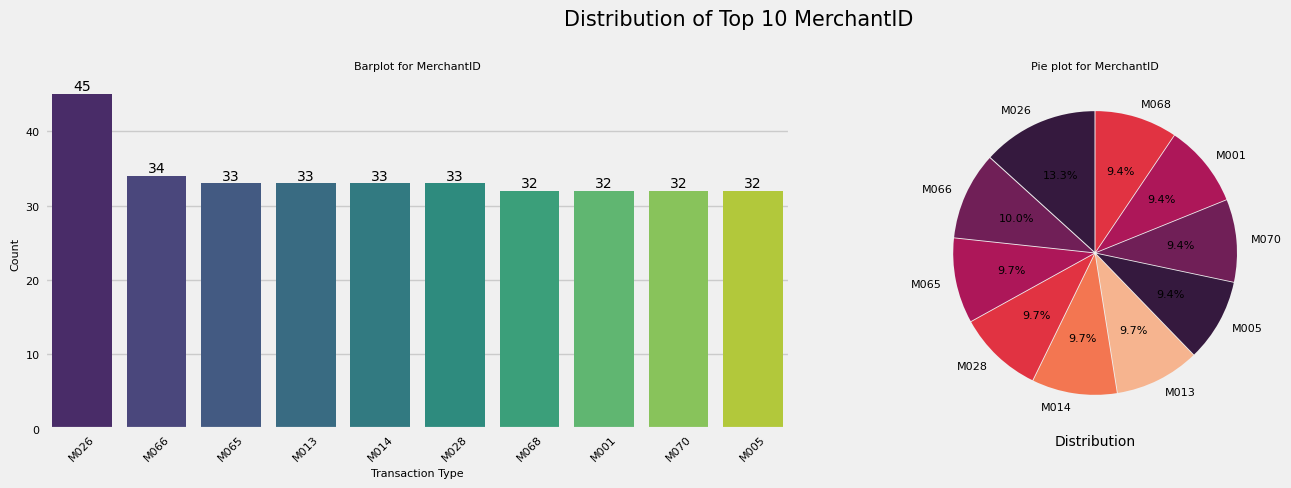

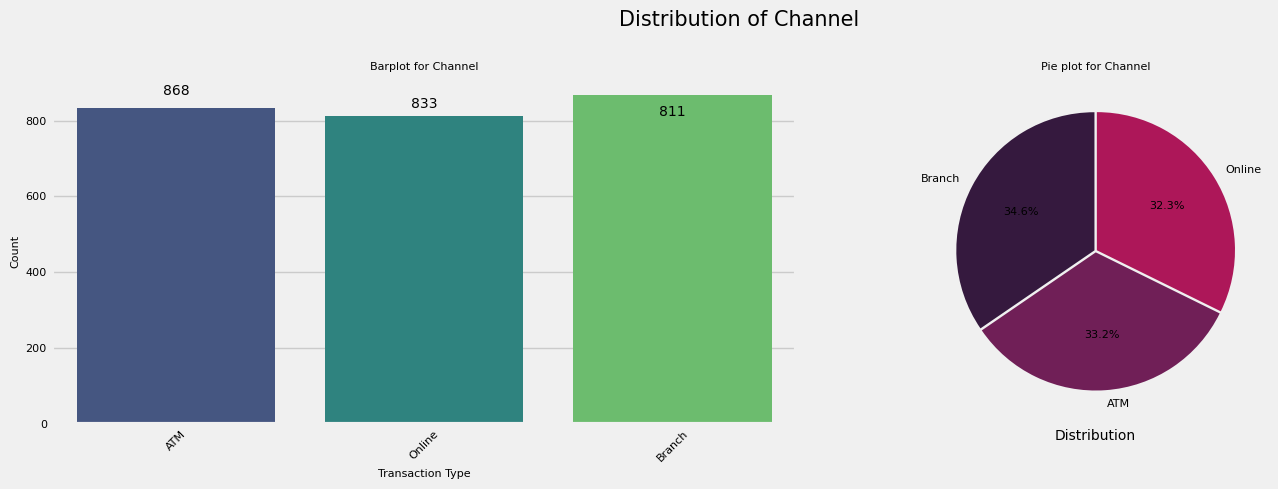

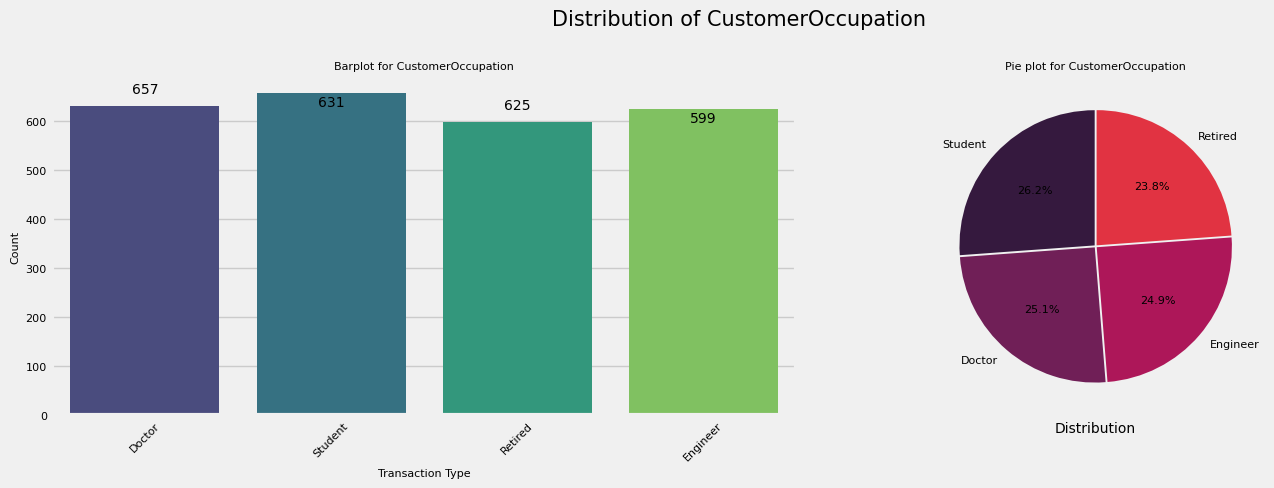

In [11]:
## Defining a function for Univariate Analysis for Categorical columns

def categorical_distribution(data, col_name):

    """
    This function visualizes the distribution of categorical variables using 
    Bar Plots and Pie Charts. It distinguishes between columns with a high number 
    of unique values (e.g., 'Location', 'DeviceID', etc.) and other categorical columns.
    
    Parameters:
    - data: pandas DataFrame containing the dataset.
    - col_name: List of categorical column names to visualize.

    Output:
    - Bar plot showing category counts.
    - Pie chart showing percentage distribution.
    """
    
    # Columns with more than 10 unique values are considered categorical
    c=['Location', 'DeviceID', 'IP Address', 'MerchantID']

    for col in col_name:

        plt.figure(figsize=(15, 5))

        # Count the frequency of each category
        if col in c:
            
            # Get the data for top N  
            top_N = data[col].value_counts().nlargest(10).index

            # Filter the data for these top
            filtered_data = data[data[col].isin(top_N)]

            category_counts = filtered_data[col].value_counts()

            # Set the overall title
            plt.suptitle(f"Distribution of Top 10 {col}", fontsize=15)

            # Barplot for categorical distribution
            plt.subplot(1, 2, 1)
            sns.countplot(data=filtered_data, x=col, palette='viridis', order=top_N)
            plt.xticks(fontsize=8,rotation=45)
            plt.yticks(fontsize=8)
            plt.title(f"Barplot for {col}",fontsize=8)
            plt.xlabel("Transaction Type", fontsize=8)
            plt.ylabel("Count", fontsize=8)

            # Add percentages on top of bars
            for i, count in enumerate(category_counts.values):
                plt.text(i, count + 0.5, f"{(count)}", ha='center', fontsize=10)

            # Pie plot for categorical distribution
            plt.subplot(1, 2, 2)
            value_counts = filtered_data[col].value_counts()
            value_counts.plot.pie(autopct='%1.1f%%', colors=sns.color_palette('rocket'), 
                                    startangle=90, explode=[0.01] * top_N.nunique(),fontsize=8,label='')
            
            plt.title(f'Pie plot for {col}', fontsize=8)
            plt.xlabel("Distribution", fontsize=10)  
            plt.xlabel("Distribution", fontsize=10)
            
            # Adjust layout
            plt.tight_layout(rect=[0, 0, 1, 1])  # Leave space for suptitle
            plt.show()

        else:

            category_counts = data[col].value_counts()

            # Set the overall title
            plt.suptitle(f"Distribution of {col}", fontsize=15)

            # Barplot for categorical distribution
            plt.subplot(1, 2, 1)
            sns.countplot(data=data, x=col, palette='viridis')
            plt.xticks(fontsize=8,rotation=45)
            plt.yticks(fontsize=8)
            plt.title(f"Barplot for {col}",fontsize=8)
            plt.xlabel("Transaction Type", fontsize=8)
            plt.ylabel("Count", fontsize=8)

            # Add counts on top of bars
            for i, count in enumerate(category_counts.values):
                plt.text(i, count + 0.5, f"{(count)}", ha='center', fontsize=10)

            # Pie plot for categorical distribution
            plt.subplot(1, 2, 2)
            value_counts = data[col].value_counts()
            value_counts.plot.pie(autopct='%1.1f%%', colors=sns.color_palette('rocket'), 
                                    startangle=90, explode=[0.01] * value_counts.nunique(),fontsize=8,label='')
            
            plt.title(f'Pie plot for {col}', fontsize=8)
            plt.xlabel("Distribution", fontsize=10)  
            plt.xlabel("Distribution", fontsize=10)
            
            # Adjust layout
            plt.tight_layout(rect=[0, 0, 1, 1])  # Leave space for suptitle
            plt.show() 

column_name=['TransactionType','Location', 'DeviceID', 'IP Address', 'MerchantID','Channel','CustomerOccupation',]

categorical_distribution(data, column_name)

### Univariate Analysis Insights

#### Numerical Columns
The numerical columns include **TransactionAmount**, **CustomerAge**, **TransactionDuration**, **LoginAttempts**, and **AccountBalance**. Below are the key trends and insights:

1. **TransactionAmount**:
   - The average transaction amount is approximately $297.59, with a wide spread (standard deviation of $291.95).
   - Most transactions are clustered below $500, with a few high-value transactions reaching up to $1919.11 (potential outliers).
   - In this boxplot, there are several outliers with transaction amounts exceeding $1,250, extending up to $2,000.
   - The distribution is skewed to the right, indicating that higher transaction amounts are more common than lower ones.
   - The median transaction amount is closer to the lower quartile, suggesting that a majority of transactions are on the lower side of the range.`

2. **CustomerAge**:
   - Ages range from 18 to 80 years, with an average of 44.67 years.
   - There is a balanced distribution, though a slight concentration is observed among middle-aged customers.

3. **TransactionDuration**:
   - The average transaction time is around 120 seconds, with durations spanning from 10 seconds to 300 seconds.
   - The data shows a positive skew, suggesting a few longer transaction times compared to the majority.

4. **LoginAttempts**:
   - Most transactions occur with just one login attempt (median = 1).
   - A small number of instances show multiple login attempts (up to 5), which could indicate suspicious activity.

5. **AccountBalance**:
   - Account balances range from $101.25 to $14,977.99, with a median balance of $4,735.51.
   - The distribution is right-skewed, with a few accounts holding significantly higher balances.

---

#### Categorical Columns
Key trends for categorical features:

1. **TransactionType**:
   - Only two types of transactions: **Debit** and **Credit**.
   - **Debit** transactions dominate the dataset.

2. **Channel**:
   - Three channels are present: **ATM**, **Online**, and possibly another minor channel.
   - **Online** and **ATM** transactions are the most frequent.

3. **Location**:
   - There are 43 unique locations, with transactions concentrated in a few major cities.
   - The top 5 locations account for a large portion of the data.

4. **CustomerOccupation**:
   - Only four occupations are recorded: e.g., **Doctor**, **Student**, and two others.
   - Students and Doctors seem to be common customer types.

5. **DeviceID** and **IP Address**:
   - Device and IP diversity are high, with 681 unique devices and 592 unique IPs.
   - Frequent repetition of the same DeviceID or IP Address could signal shared or fraudulent activity.

### 2. Bi-variate Analysis

#### 2.1 Numerical vs. Categorical Features

- `TransactionAmount` vs. `TransactionType` (Debit/Credit)

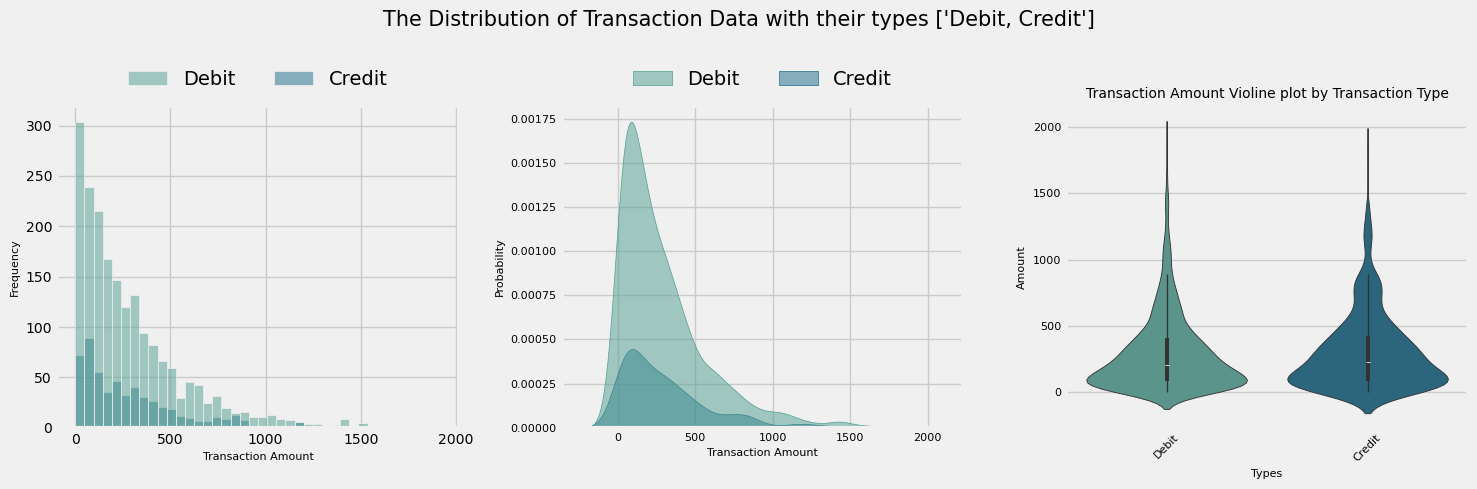

In [12]:
plt.figure(figsize=(15, 5))

# Set the overall title
plt.suptitle("The Distribution of Transaction Data with their types ['Debit, Credit']", fontsize=15)

# Histogram on the left
plt.subplot(1, 3, 1)
ax=sns.histplot(data=data, x="TransactionAmount", kde=False, palette="crest", hue='TransactionType')
sns.move_legend(ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Transaction Amount", fontsize=8)
plt.ylabel("Frequency", fontsize=8)

# Scatter plot on the right
plt.subplot(1, 3, 2)
ax1=sns.kdeplot(data=data, x="TransactionAmount", alpha=0.5, hue='TransactionType',linewidth=0.5,fill=True,common_norm=True, palette="crest")
sns.move_legend(ax1, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel("Transaction Amount", fontsize=8)
plt.ylabel("Probability", fontsize=8)

# Violine plot on the right
plt.subplot(1, 3, 3)
sns.violinplot(x='TransactionType', y='TransactionAmount', data=data, palette='crest')
plt.title('Transaction Amount Violine plot by Transaction Type',fontsize=10)
plt.xlabel('Types',fontsize=8)
plt.ylabel('Amount',fontsize=8)
plt.xticks(fontsize=8, rotation=45)
plt.yticks(fontsize=8)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 1])  # Leave space for suptitle
plt.show()

**General Observations:**

1. `Debit transactions dominate the dataset in both frequency and occurrence.`
2. `Most transactions (debit and credit) involve small amounts, with only a few high-value transactions present.`
3. `The distributions show clear skewness, highlighting the presence of outliers or infrequent high-value transactions.`
4. `The scatterplot reinforces the dominance of debit transactions while highlighting sporadic patterns for credit transactions.`

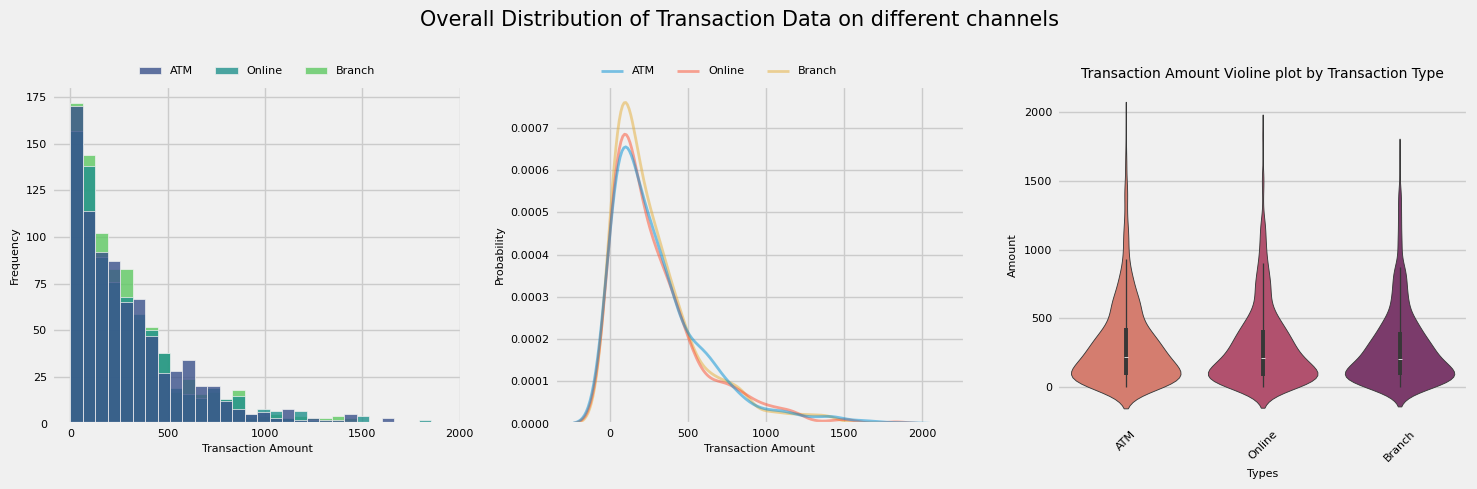

In [13]:
plt.figure(figsize=(15, 5))

# Set the overall title
plt.suptitle("Overall Distribution of Transaction Data on different channels", fontsize=15)

# Histogram on the left
plt.subplot(1, 3, 1)
ax=sns.histplot(data=data, x="TransactionAmount", kde=False,hue="Channel", bins=30, palette='viridis', alpha=0.8)
sns.move_legend(ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,fontsize=8
)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel("Transaction Amount", fontsize=8)
plt.ylabel("Frequency", fontsize=8)

# KDE plot on the right
plt.subplot(1, 3, 2)
ax1=sns.kdeplot(data=data, x="TransactionAmount", alpha=0.5, hue='Channel',linewidth=2,fill=False,common_norm=True)
sns.move_legend(ax1, "lower center",
    bbox_to_anchor=(.4, 1), ncol=3, title=None, frameon=False,fontsize=8
)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel("Transaction Amount", fontsize=8)
plt.ylabel("Probability", fontsize=8)

# Violine plot on the right
plt.subplot(1, 3, 3)
sns.violinplot(x='Channel', y='TransactionAmount', data=data, palette='flare')
plt.title('Transaction Amount Violine plot by Transaction Type',fontsize=10)
plt.xlabel('Types',fontsize=8)
plt.ylabel('Amount',fontsize=8)
plt.xticks(fontsize=8,rotation=45)
plt.yticks(fontsize=8)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 1])  # Leave space for suptitle
plt.show()

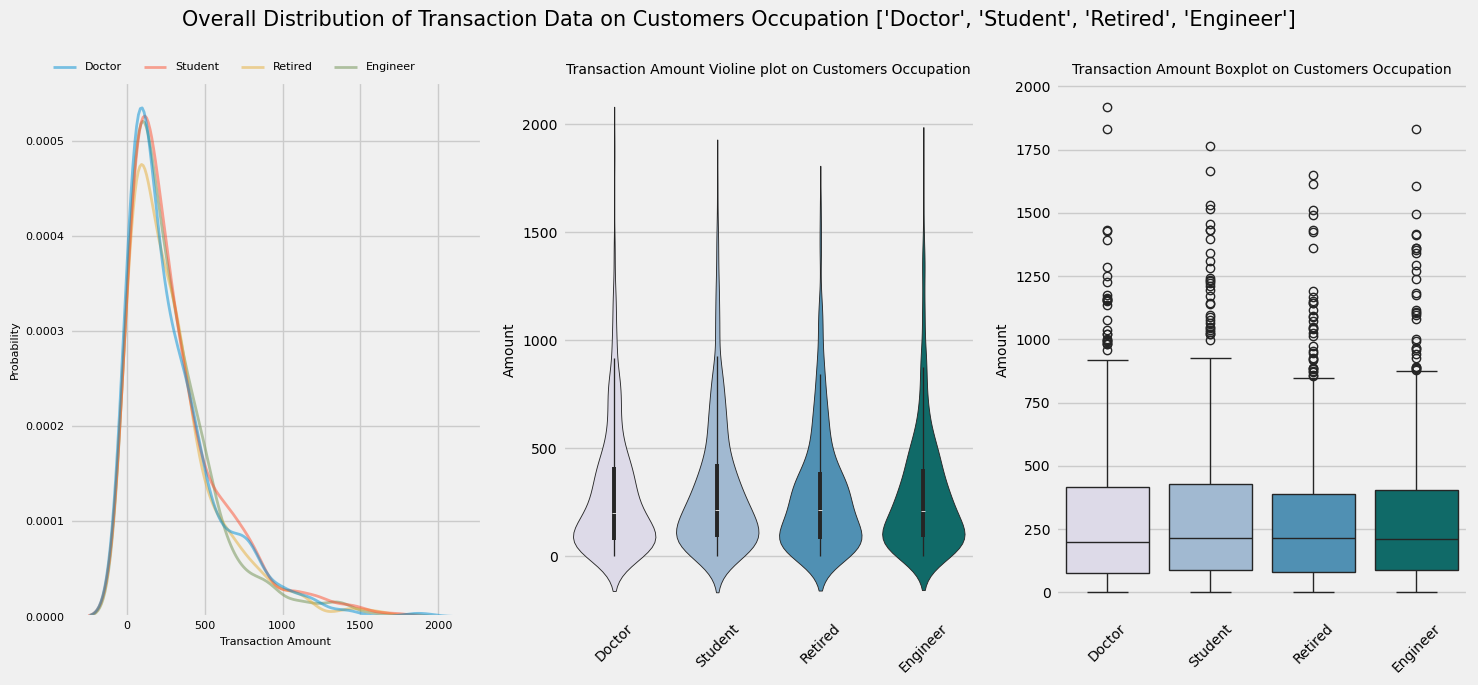

In [14]:
## Here I am not using Histplot because the 'CustomerOccupation' have more than 3 unique values and it is not easy to read the plot.

plt.figure(figsize=(15, 7))

# Set the overall title
plt.suptitle(f"Overall Distribution of Transaction Data on Customers Occupation {list(data['CustomerOccupation'].unique())}", fontsize=15)

# Pie plot on the left
plt.subplot(1, 3, 1)
ax1=sns.kdeplot(data=data, x="TransactionAmount", alpha=0.5, hue='CustomerOccupation',linewidth=2,fill=False,common_norm=True)
sns.move_legend(ax1, "lower center",
    bbox_to_anchor=(.4, 1), ncol=4, title=None, frameon=False,fontsize=8
)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel("Transaction Amount", fontsize=8)
plt.ylabel("Probability", fontsize=8)

# Violine plot on the right
plt.subplot(1, 3, 2)
sns.violinplot(x='CustomerOccupation', y='TransactionAmount', data=data, palette='PuBuGn')
plt.title('Transaction Amount Violine plot on Customers Occupation',fontsize=10)
plt.xlabel('',fontsize=10)
plt.ylabel('Amount',fontsize=10)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)

# Box plot on the right
plt.subplot(1, 3, 3)
sns.boxplot(x='CustomerOccupation', y='TransactionAmount', data=data, palette='PuBuGn')
plt.title('Transaction Amount Boxplot on Customers Occupation',fontsize=10)
plt.xlabel('',fontsize=10)
plt.ylabel('Amount',fontsize=10)
plt.xticks(fontsize=10,rotation=45)
plt.yticks(fontsize=10)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 1])  # Leave space for suptitle
plt.show()

---

- ***Top 10% High Value*** `TransactionAmount` vs. `TransactionType`, `Channel` & `CustomerOccupation`

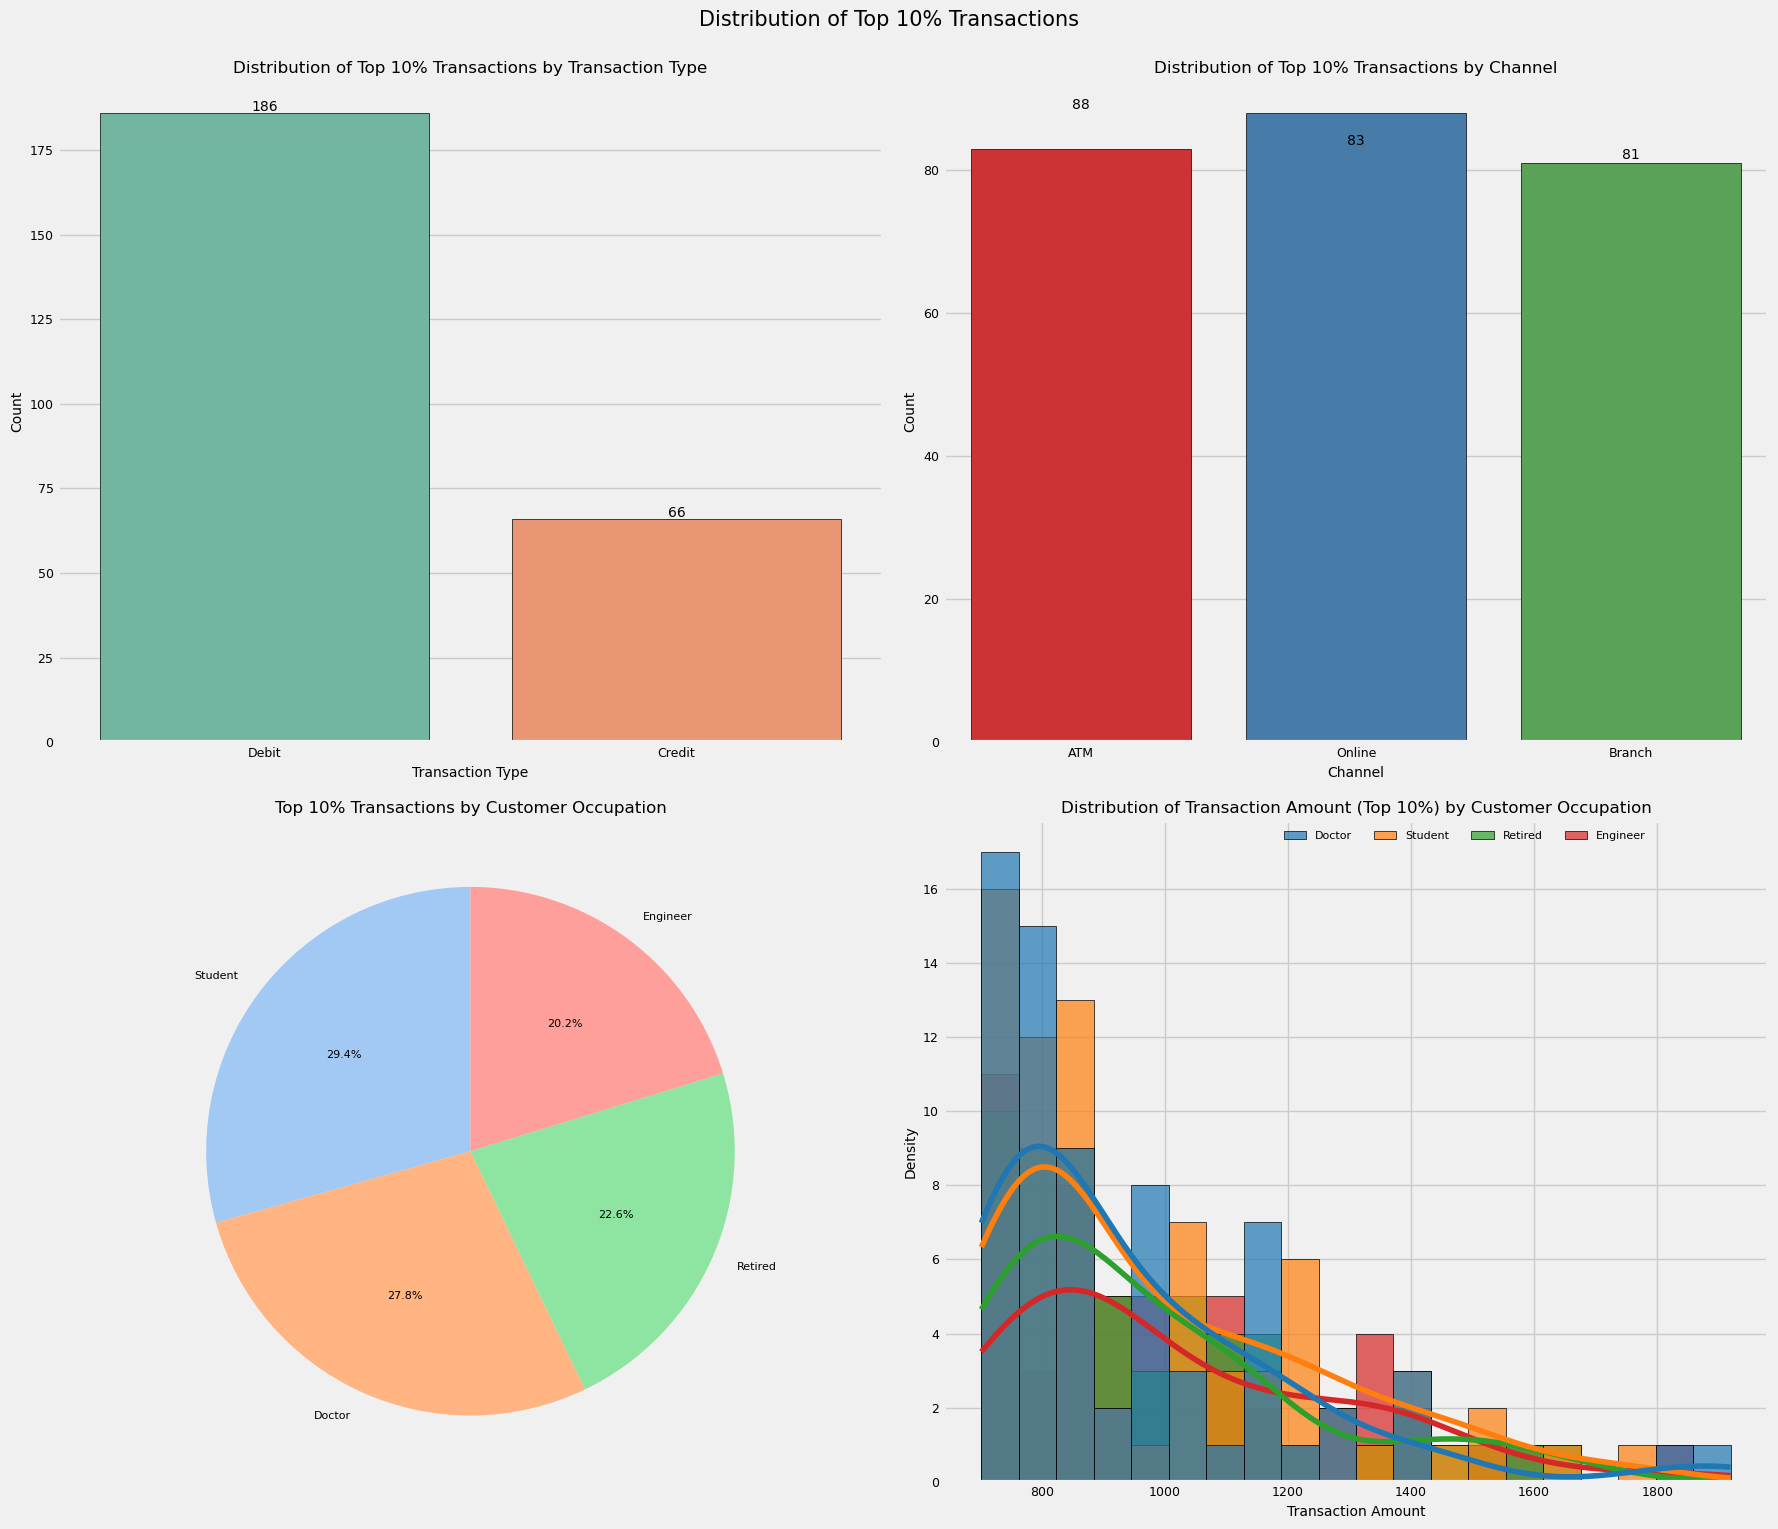

Number of transactions in the top 10%: 252


In [15]:
# Filter the top 10% transactions
threshold = data['TransactionAmount'].quantile(0.90) # 90th percentile for filtering Top 10%
top_10_percent_data = data[data['TransactionAmount'] > threshold]

# Plot the distributions
plt.figure(figsize=(18, 15))

# Bar plot for Transaction Type
plt.subplot(2, 2, 1)
sns.countplot(data=top_10_percent_data, x='TransactionType', palette='Set2',edgecolor='black')
plt.title("Distribution of Top 10% Transactions by Transaction Type", fontsize=12)
plt.xlabel("Transaction Type", fontsize=10)
plt.ylabel("Count", fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

category_counts=top_10_percent_data['TransactionType'].value_counts()

for i, count in enumerate(category_counts.values):
                plt.text(i, count + 0.5, f"{(count)}", ha='center', fontsize=10)

# Bar plot for Channel
plt.subplot(2, 2, 2)
sns.countplot(data=top_10_percent_data, x='Channel', palette='Set1',edgecolor='black')
plt.title("Distribution of Top 10% Transactions by Channel", fontsize=12)
plt.xlabel("Channel", fontsize=10)
plt.ylabel("Count", fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

category_counts=top_10_percent_data['Channel'].value_counts()

for i, count in enumerate(category_counts.values):
    plt.text(i, count + 0.5, f"{(count)}", ha='center', fontsize=10)

# Pie chart for Customer Occupation
plt.subplot(2, 2, 3)
occupation_counts = top_10_percent_data['CustomerOccupation'].value_counts()
plt.pie(occupation_counts, labels=occupation_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('pastel', len(occupation_counts)),
        textprops={'fontsize': 8})
plt.title("Top 10% Transactions by Customer Occupation", fontsize=12)

# Histogram with KDE for Transaction Amount distribution by Customer Occupation
plt.subplot(2, 2, 4)
ax=sns.histplot(
    data=top_10_percent_data,
    x='TransactionAmount',
    hue='CustomerOccupation',
    kde=True,
    palette='tab10',
    bins=20,
    alpha=0.7,
    linewidth=0.5,
    edgecolor='black'
)

sns.move_legend(ax, "upper left",
    bbox_to_anchor=(.4, 1), ncol=4, title=None, frameon=False, fontsize=8
)

plt.title("Distribution of Transaction Amount (Top 10%) by Customer Occupation", fontsize=12)
plt.xlabel("Transaction Amount", fontsize=10)
plt.ylabel("Density", fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

# Adjust layout and show the plot
plt.tight_layout()
plt.suptitle("Distribution of Top 10% Transactions", fontsize=15, y=1.02)
plt.show()

print(f'Number of transactions in the top 10%: {len(top_10_percent_data)}')

---

- `TransactionAmount` vs. `LoginAttempts`

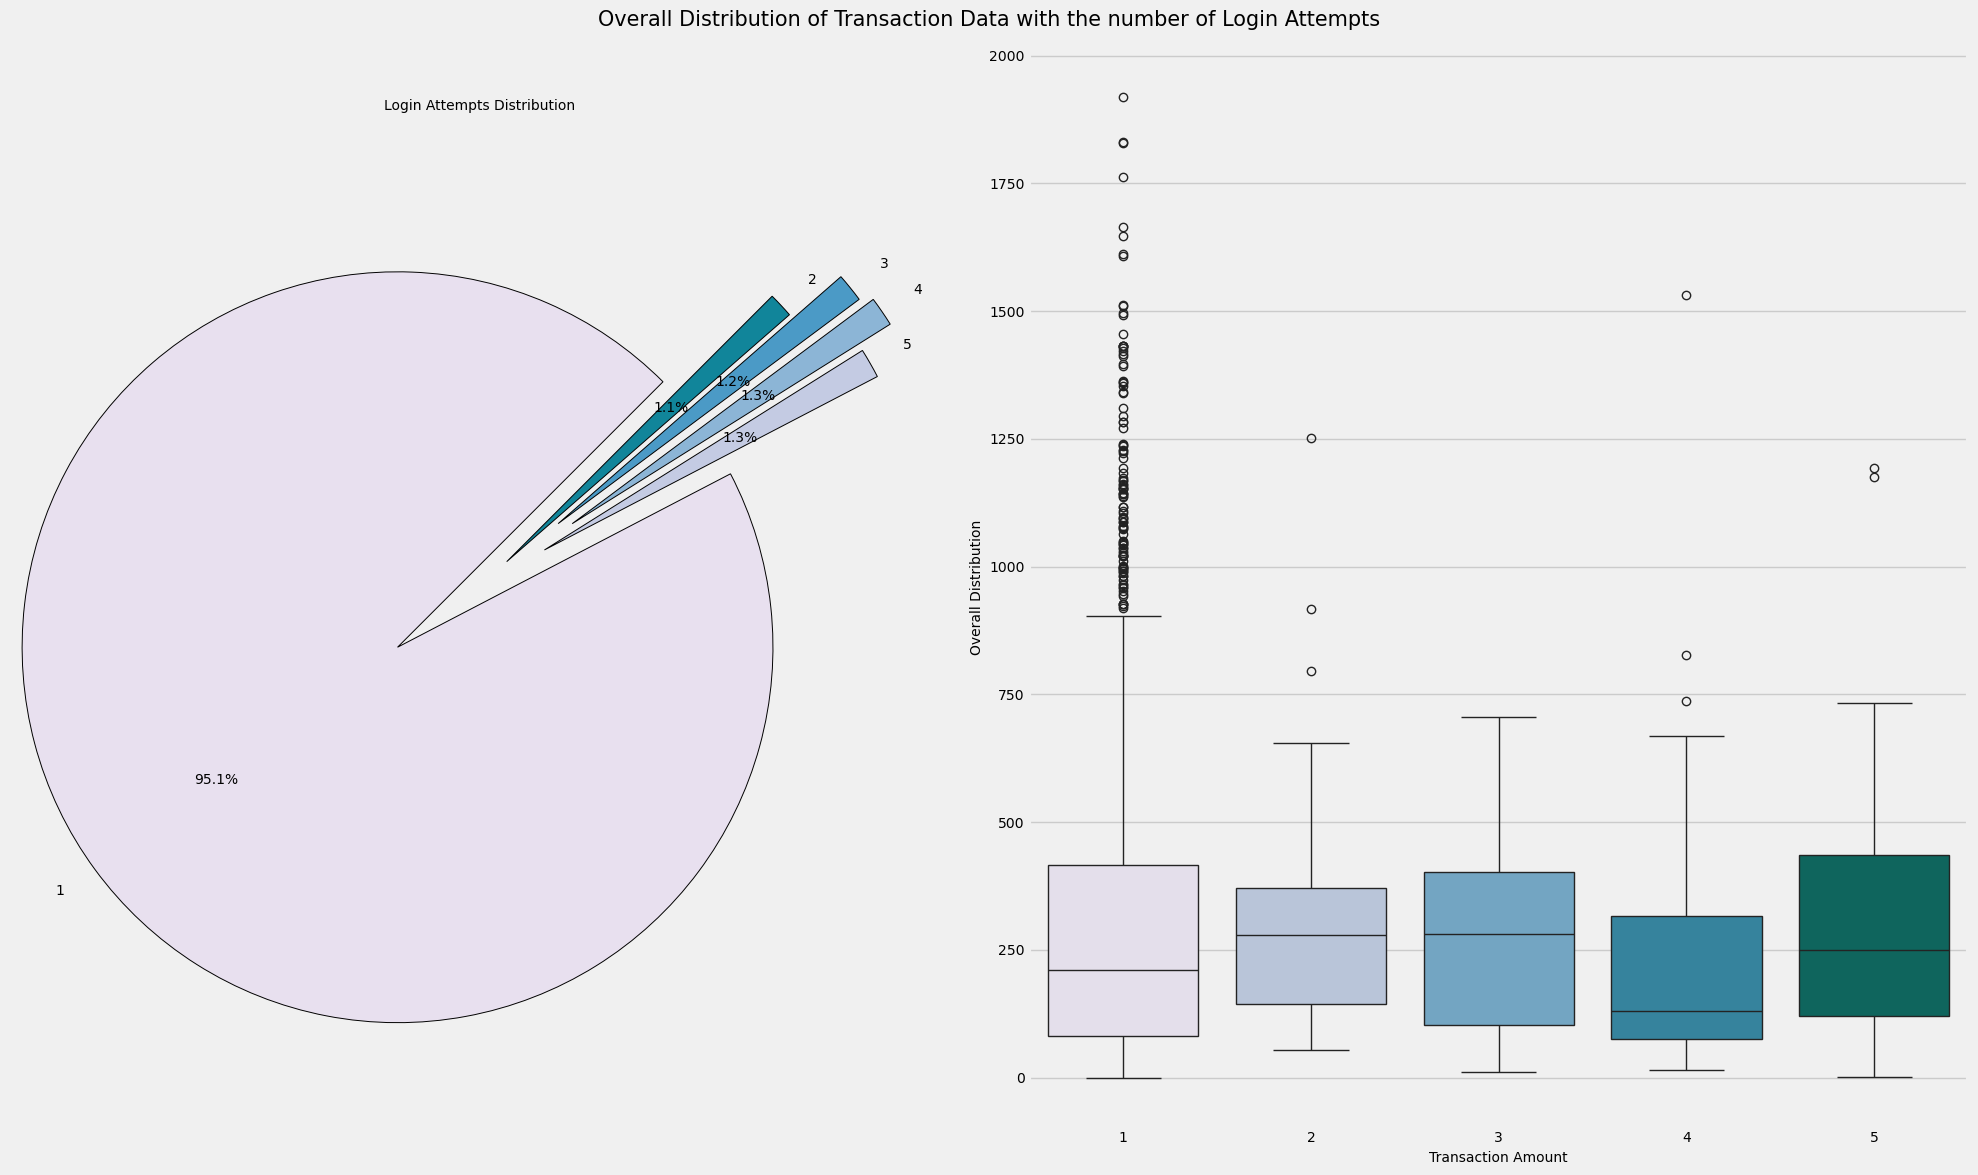

In [16]:
plt.figure(figsize=(20, 12))

# Set the overall title
plt.suptitle("Overall Distribution of Transaction Data with the number of Login Attempts", fontsize=15)


# Pie plot on the left
plt.subplot(1, 2, 1)
value_counts = data['LoginAttempts'].value_counts()
explode = [0.27, 0.2, 0.3, 0.27, 0.1]
value_counts.plot.pie(autopct='%1.1f%%', colors=sns.color_palette('PuBuGn'), 
                               startangle=45,explode=explode,fontsize=10,wedgeprops={'linewidth': 0.7, 'edgecolor': 'black'})
        
plt.title('Login Attempts Distribution', fontsize=10)
plt.ylabel('')  

# Box plot on the right (Considering Login Attempts as Categorical column)
plt.subplot(1, 2, 2)

sns.boxplot(x='LoginAttempts', y='TransactionAmount', data=data, palette='PuBuGn')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Transaction Amount", fontsize=10)
plt.ylabel("Overall Distribution", fontsize=10)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 1])  # Leave space for suptitle
plt.show()

Transactions with other than One Login Attempts: 122


,TransactionAmount,TransactionType,Channel,LoginAttempts
61,263.99,Debit,Branch,2
677,375.17,Debit,ATM,2
414,83.50,Debit,Branch,5
2073,441.26,Credit,Branch,5
772,827.14,Debit,Branch,4


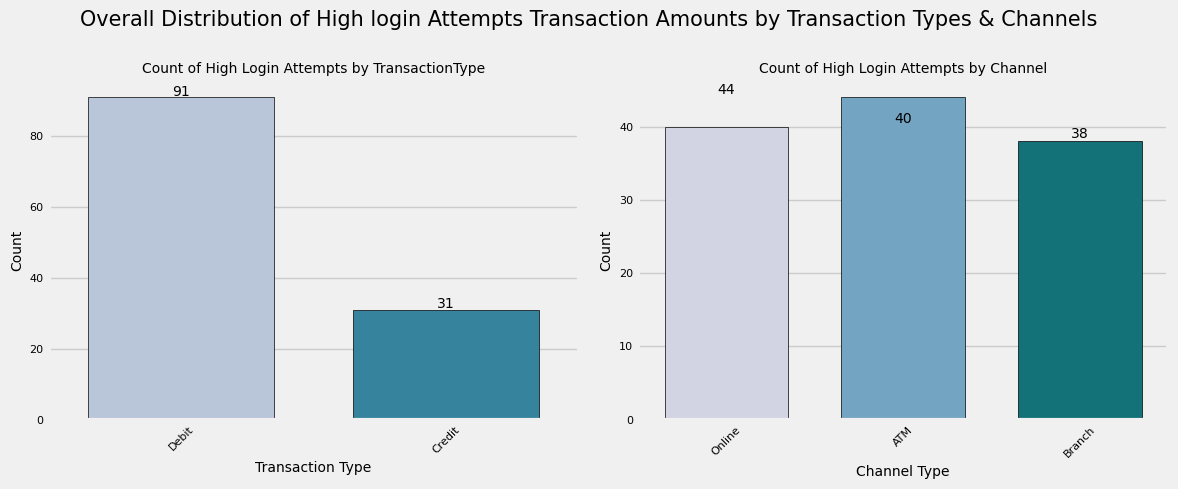

In [17]:
## Creating subset for the Transaction of High login attempts
high_login_subset=data[data['LoginAttempts']>1]
print(f'Transactions with other than One Login Attempts: {len(high_login_subset)}')
display(high_login_subset[['TransactionAmount','TransactionType','Channel','LoginAttempts']].sample(5))

## Visualizing the Data
plt.figure(figsize=(12, 5))

# Set the overall title
plt.suptitle("Overall Distribution of High login Attempts Transaction Amounts by Transaction Types & Channels", fontsize=15)

plt.subplot(1, 2, 1)
sns.countplot(data=high_login_subset, x='TransactionType', palette='PuBuGn',width=0.7,edgecolor='black')
plt.title('Count of High Login Attempts by TransactionType',fontsize=10)
plt.xticks(fontsize=8,rotation=45)
plt.yticks(fontsize=8)
plt.xlabel('Transaction Type',fontsize=10)
plt.ylabel('Count', fontsize=10)

category_counts=high_login_subset['TransactionType'].value_counts()

for i, count in enumerate(category_counts.values):
    plt.text(i, count + 0.5, f"{(count)}", ha='center', fontsize=10)


 
plt.subplot(1, 2, 2)
sns.countplot(data=high_login_subset, x='Channel', palette='PuBuGn',width=0.7,edgecolor='black')
plt.title('Count of High Login Attempts by Channel',fontsize=10)
plt.xticks(fontsize=8,rotation=45)
plt.yticks(fontsize=8)
plt.xlabel('Channel Type',fontsize=10)
plt.ylabel('Count',fontsize=10)

category_counts=high_login_subset['Channel'].value_counts()

for i, count in enumerate(category_counts.values):
    plt.text(i, count + 0.5, f"{(count)}", ha='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 1]) # To ensure the subplots are not overlapping
plt.show()

The image displays **two bar plots side by side** to analyze the distribution of high login attempts based on **Transaction Type** and **Channel Type**. It will help us to understand which transaction type and channel type are more prone to high login attempts.

### Observations/Insights:
- High login attempts are predominantly associated with **Debit transactions**.
- Among the channels, **Online transactions** experience the highest number of high login attempts, indicating potential areas for security enhancements in online platforms.
- **Branch and ATM channels** also show notable counts of high login attempts, but these are lower compared to Online.

---



- `TransactionAmount` vs. `TransactionType` by. Top 10 `Location`

In [18]:
# The top 10 locations based on the total TransactionAmount
top_locations = data.groupby('Location')['TransactionAmount'].sum().nlargest(10).index

# Filter the data for these top 10 locations
filtered_data = data[data['Location'].isin(top_locations)]

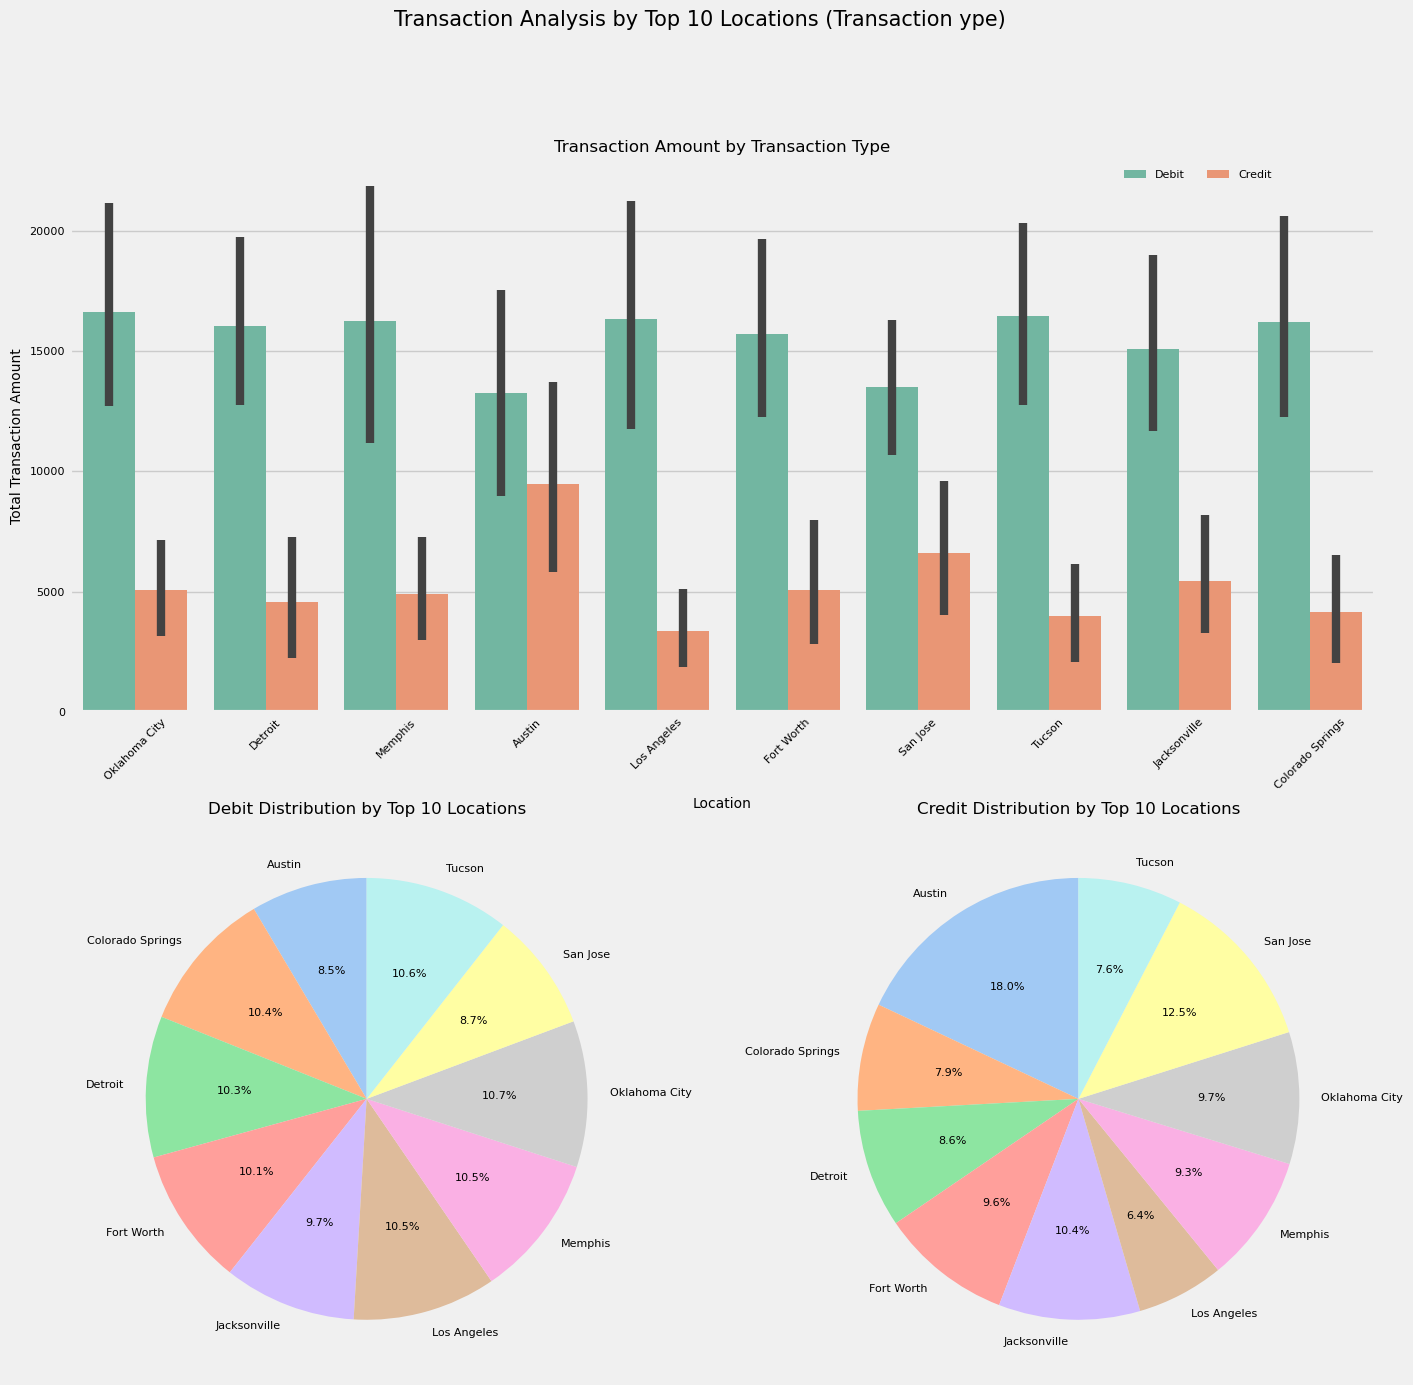

In [19]:
# Separate data by Occupation
types = filtered_data['TransactionType'].unique()
types_data = {ty: filtered_data[filtered_data['TransactionType'] == ty] for ty in types}

# Set up the plots
fig = plt.figure(figsize=(15, 15))
fig.suptitle("Transaction Analysis by Top 10 Locations (Transaction ype)", fontsize=15)

# Bar plot for Transaction Amount by Occupation
ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=3)
sns.barplot(
    data=filtered_data, 
    x='Location', 
    y='TransactionAmount', 
    hue='TransactionType', 
    palette='Set2', 
    estimator=sum, 
    ax=ax1
)
# Modify the legends for bar plot
sns.move_legend(ax1, "upper left",
    bbox_to_anchor=(.8, 1), ncol=2, title=None, frameon=False, fontsize=8
)

ax1.set_title("Transaction Amount by Transaction Type", fontsize=12)
ax1.set_xlabel("Location", fontsize=10)
ax1.set_ylabel("Total Transaction Amount", fontsize=10)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', labelsize=8)

# Generate Pie charts for each Occupation
for idx, (type, data_subset) in enumerate(types_data.items()):
    ax = plt.subplot2grid((2, 2), (1, idx))
    types_totals = data_subset.groupby('Location')['TransactionAmount'].sum()
    ax.pie(
        types_totals, 
        labels=types_totals.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=sns.color_palette('pastel', len(types_totals)),
        textprops={'fontsize': 8}  # Set font size for labels
    )
    ax.set_title(f"{type} Distribution by Top 10 Locations", fontsize=12)

# Adjust layout
plt.tight_layout(rect=[1, 1, 0, 0.95])
plt.show()

---

- `TransactionAmount` vs. `Channel` by. Top 10 `Location`

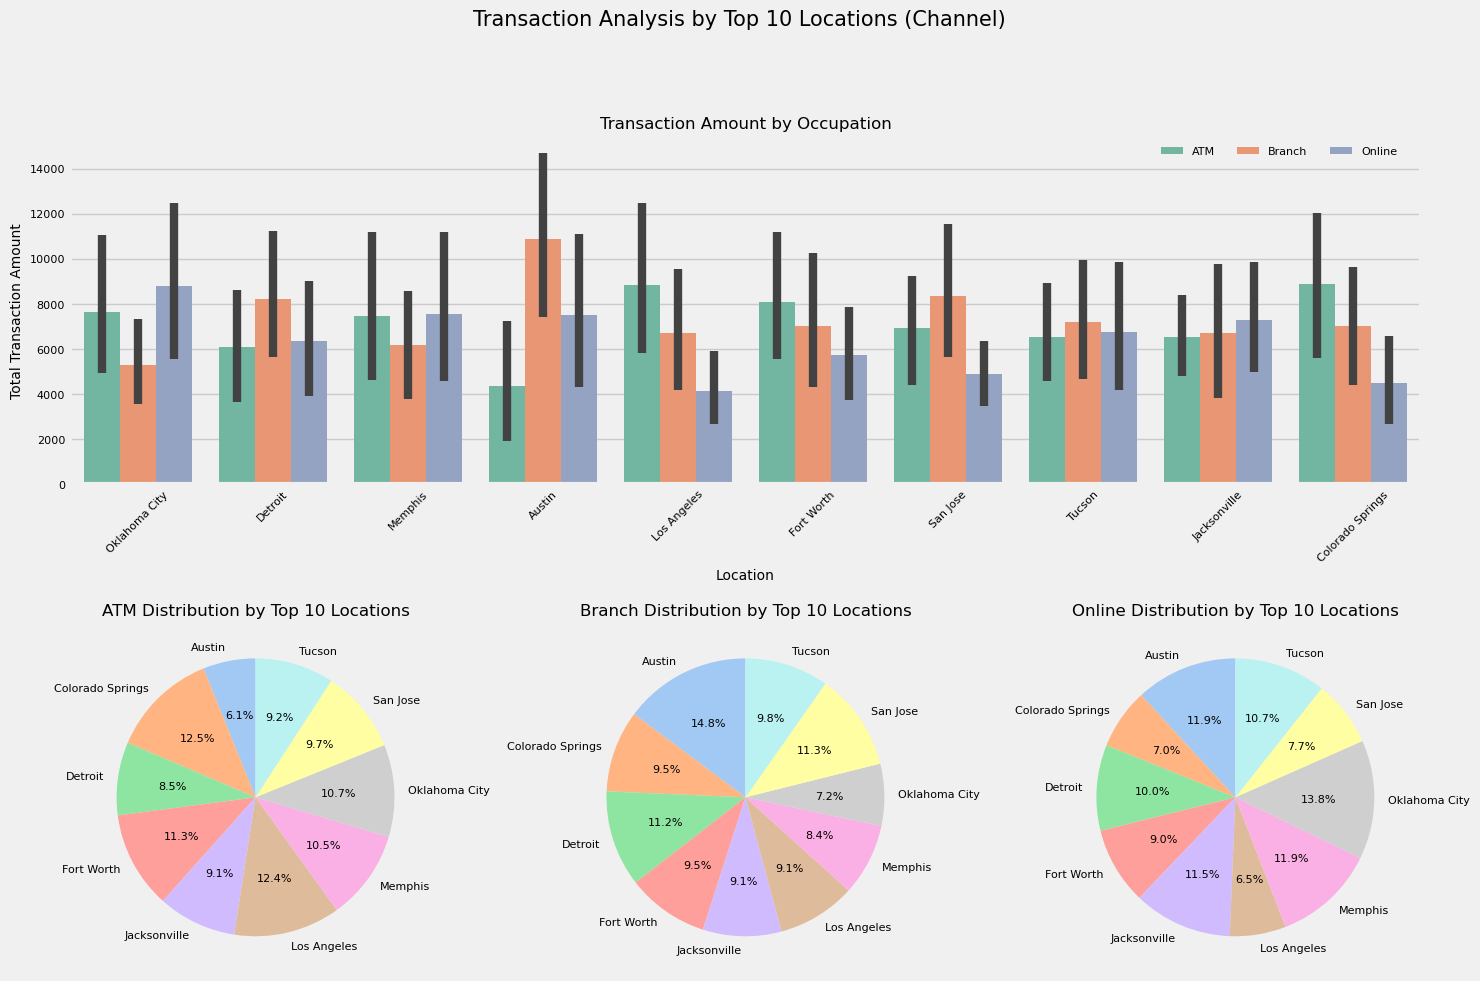

In [20]:
# Separate data by Occupation
channels = filtered_data['Channel'].unique()
channels_data = {ch: filtered_data[filtered_data['Channel'] == ch] for ch in channels}

# Set up the plots
fig = plt.figure(figsize=(15, 15))
fig.suptitle("Transaction Analysis by Top 10 Locations (Channel)", fontsize=15)

# Bar plot for Transaction Amount by Occupation
ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=3)
sns.barplot(
    data=filtered_data, 
    x='Location', 
    y='TransactionAmount', 
    hue='Channel', 
    palette='Set2', 
    estimator=sum, 
    ax=ax1
)
# Modify the legends for bar plot
sns.move_legend(ax1, "upper left",
    bbox_to_anchor=(.8, 1), ncol=4, title=None, frameon=False, fontsize=8
)

ax1.set_title("Transaction Amount by Occupation", fontsize=12)
ax1.set_xlabel("Location", fontsize=10)
ax1.set_ylabel("Total Transaction Amount", fontsize=10)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', labelsize=8)

# Generate Pie charts for each Occupation
for idx, (channel, data_subset) in enumerate(channels_data.items()):
    ax = plt.subplot2grid((3, 3), (1, idx % 3))
    channels_totals = data_subset.groupby('Location')['TransactionAmount'].sum()
    ax.pie(
        channels_totals, 
        labels=channels_totals.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=sns.color_palette('pastel', len(channels_totals)),
        textprops={'fontsize': 8}  # Set font size for labels
    )
    ax.set_title(f"{channel} Distribution by Top 10 Locations", fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---

- `TransactionAmount` vs. `CustomerOccupation` by. Top 10 `Location`

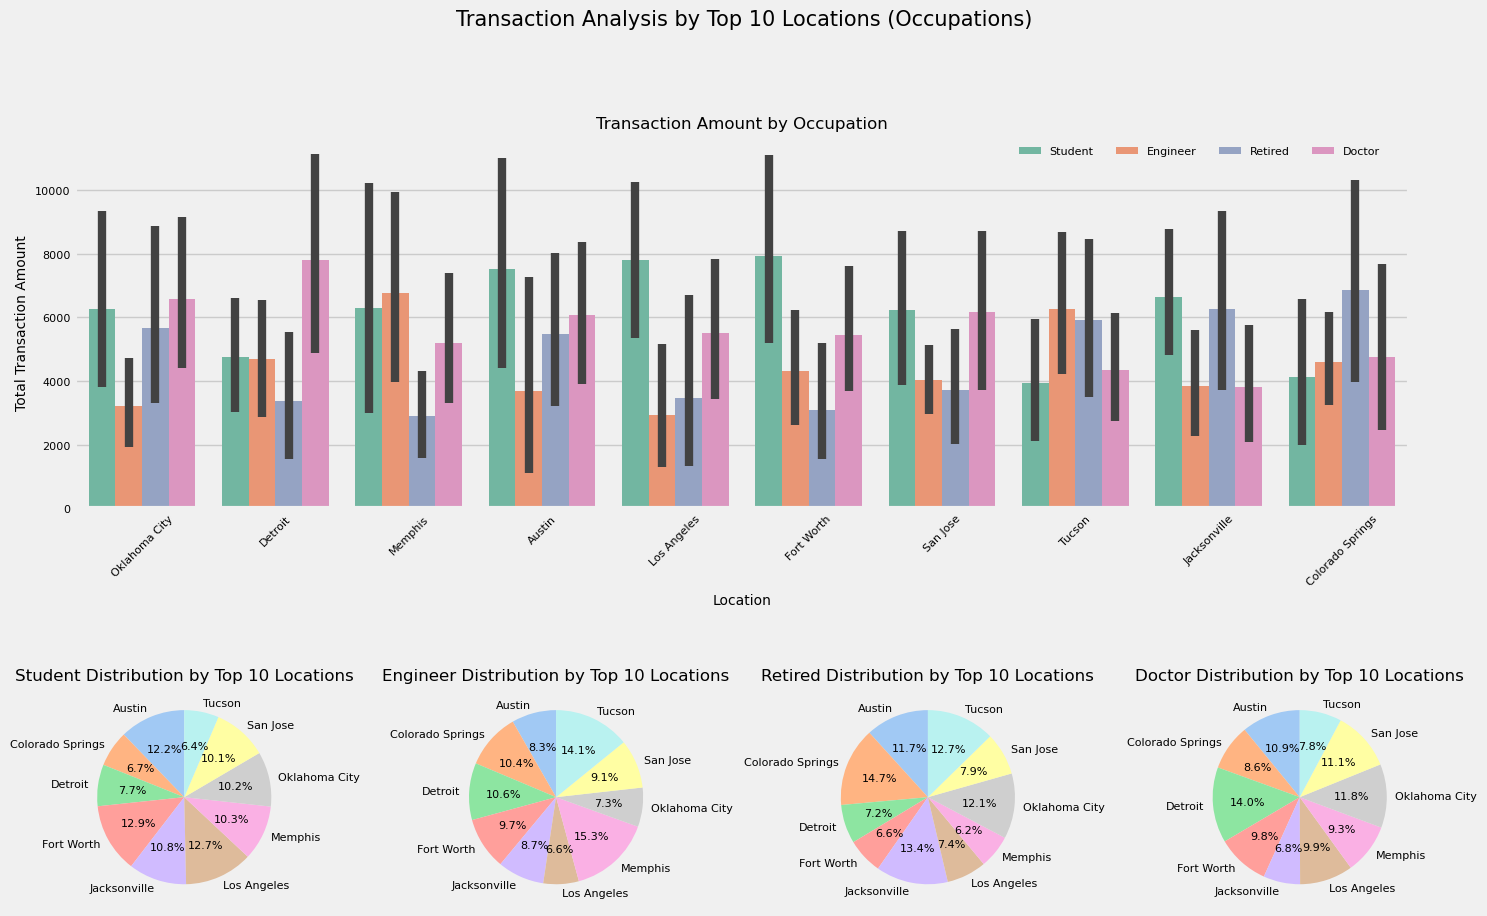

In [21]:
# Separate data by Occupation
occupations = filtered_data['CustomerOccupation'].unique()
occupation_data = {occ: filtered_data[filtered_data['CustomerOccupation'] == occ] for occ in occupations}

# Set up the plots
fig = plt.figure(figsize=(15, 15))
fig.suptitle("Transaction Analysis by Top 10 Locations (Occupations)", fontsize=15)

# Bar plot for Transaction Amount by Occupation
ax1 = plt.subplot2grid((3, 4), (0, 0), colspan=4)
sns.barplot(
    data=filtered_data, 
    x='Location', 
    y='TransactionAmount', 
    hue='CustomerOccupation', 
    palette='Set2',  
    estimator=sum, 
    ax=ax1
)
# Modify the legends for bar plot
sns.move_legend(ax1, "upper left",
    bbox_to_anchor=(.7, 1), ncol=4, title=None, frameon=False, fontsize=8
)

ax1.set_title("Transaction Amount by Occupation", fontsize=12)
ax1.set_xlabel("Location", fontsize=10)
ax1.set_ylabel("Total Transaction Amount", fontsize=10)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', labelsize=8)

# Generate Pie charts for each Occupation
for idx, (occupation, data_subset) in enumerate(occupation_data.items()):
    ax = plt.subplot2grid((3, 4), (1, idx % 4))
    occupation_totals = data_subset.groupby('Location')['TransactionAmount'].sum()
    ax.pie(
        occupation_totals, 
        labels=occupation_totals.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=sns.color_palette('pastel', len(occupation_totals)),
        textprops={'fontsize': 8}  # Set font size for labels
    )
    ax.set_title(f"{occupation} Distribution by Top 10 Locations", fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---

- `AccountBalance` vs. `Location`

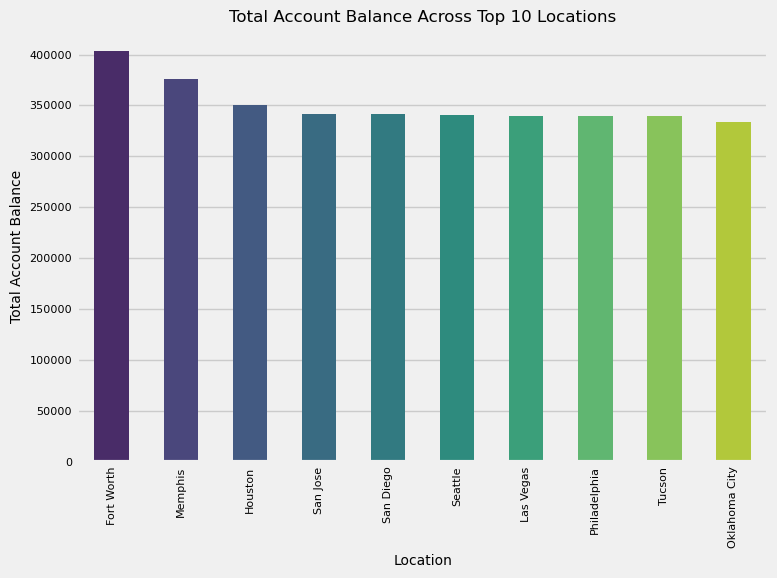

In [22]:
# Get the top 10 locations based on total AccountBalance
top_locations = data.groupby('Location')['AccountBalance'].sum().nlargest(10).index

# Filter the data for these top 10 locations
filtered_data = data[data['Location'].isin(top_locations)]

# Aggregate the total AccountBalance for each location
location_account_balance = filtered_data.groupby('Location')['AccountBalance'].sum().sort_values(ascending=False)

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(
    x=location_account_balance.index, 
    y=location_account_balance.values, 
    palette="viridis",
    width=0.5
)

# Customize the plot
plt.title('Total Account Balance Across Top 10 Locations', fontsize=12)
plt.xlabel('Location', fontsize=10)
plt.ylabel('Total Account Balance', fontsize=10)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)

# Display the plot
plt.tight_layout()
plt.show()


---

- `TransactionAmount` vs. `IP Address` by. `Location` on Map

In [ ]:
import folium
from folium.plugins import HeatMap
import geoip2.database

# Taking subset of the data
loc_data=data[['TransactionAmount', 'IP Address']]

# Geolocating IP addresses using geoip2
# Download GeoLite2 database from https://www.maxmind.com/en/geolite2-free-geolocation-data and attach the 'GeoLite2-City.mmdb' file here
reader = geoip2.database.Reader(r"C:\Users\erpra\Documents\ExploratoryDataAnalysis\Bank Transaction Dataset for Fraud Detection\GeoLite2-City.mmdb")  

locations = []
for ip in loc_data['IP Address']:
    try:
        response = reader.city(ip)
        latitude = response.location.latitude
        longitude = response.location.longitude
        locations.append((latitude, longitude))
    except Exception as e:
        locations.append((None, None))  # Handle private or invalid IPs

loc_data['Latitude'], loc_data['Longitude'] = zip(*locations)

# Filtering valid coordinates
loc_data = loc_data.dropna(subset=['Latitude', 'Longitude'])

# Creating a map
m = folium.Map(location=[0, 0], zoom_start=2)  # Initialize map

# Adding heatmap layer
heat_data = [
    [row['Latitude'], row['Longitude'], row['TransactionAmount']]
    for index, row in loc_data.iterrows()
]
HeatMap(heat_data).add_to(m)

# Adding location pins
for index, row in loc_data.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"IP: {row['IP Address']}<br>Amount: ${row['TransactionAmount']}",
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(m)

# Saving map as an HTML file
m.save("transaction_heatmap_with_pins.html")

# Displaying map
m

---

#### 2.2 Categorical vs. Categorical Features

- `TransactionType` vs. `Channel`

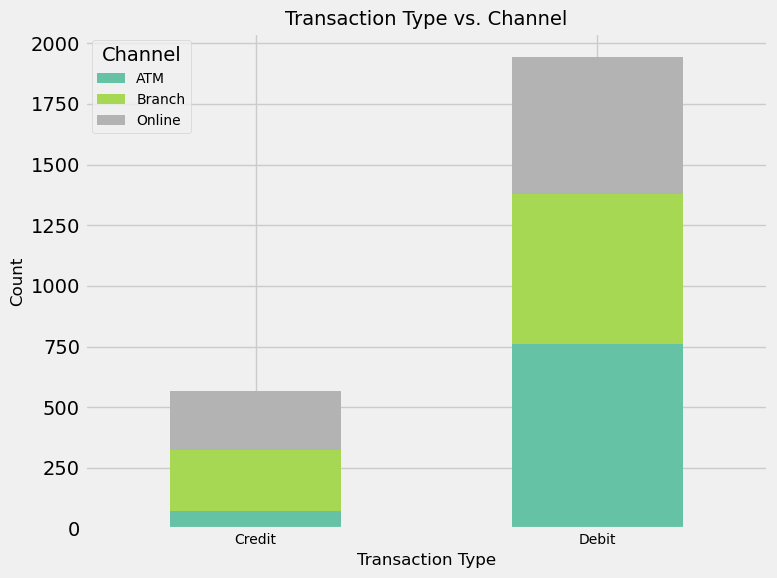

In [ ]:
# Grouping data by TransactionType and Channel
type_channel = data.groupby(['TransactionType', 'Channel']).size().unstack()

# Stacked bar chart
type_channel.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='Set2')
plt.title("Transaction Type vs. Channel", fontsize=14)
plt.xlabel("Transaction Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.legend(title='Channel', fontsize=10)
plt.tight_layout()
plt.show()


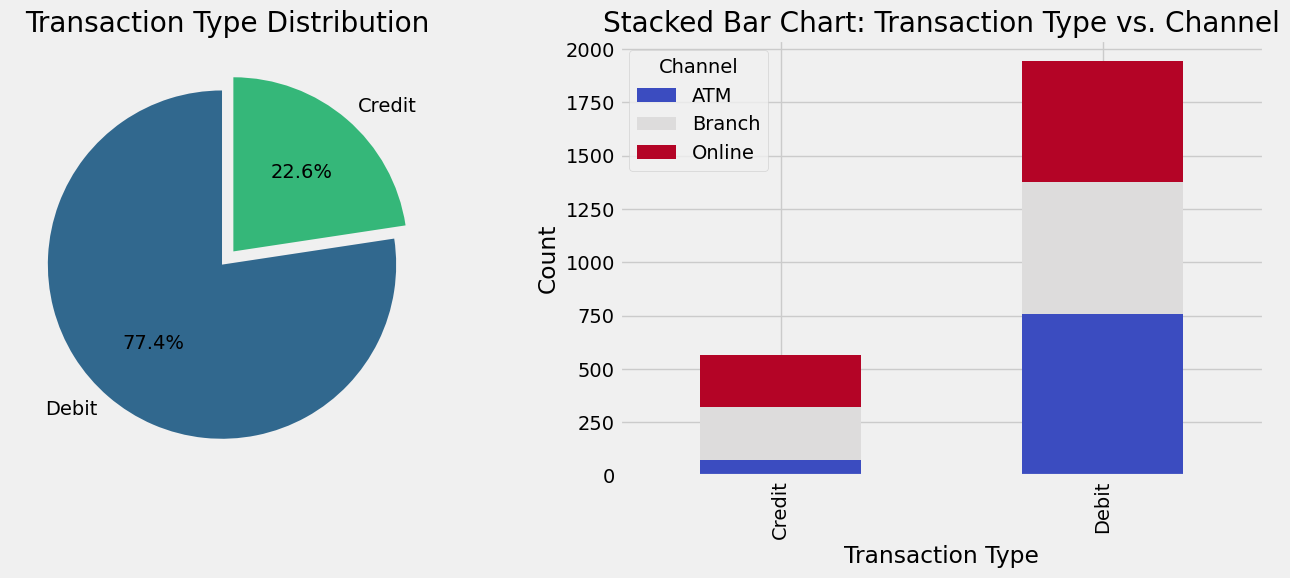

In [37]:
transaction_counts = data['TransactionType'].value_counts()
transaction_channel_counts = pd.crosstab(data['TransactionType'], data['Channel'])

# Create the subplot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 🎯 Pie Chart for Transaction Type Distribution
axes[0].pie(transaction_counts, labels=transaction_counts.index, autopct='%1.1f%%', 
            colors=sns.color_palette("viridis", len(transaction_counts)), startangle=90, explode=[0.05]*len(transaction_counts))
axes[0].set_title("Transaction Type Distribution")

# 🎯 Stacked Bar Chart for Transaction Type vs. Channel
transaction_channel_counts.plot(kind='bar', stacked=True, colormap='coolwarm', ax=axes[1])
axes[1].set_title("Stacked Bar Chart: Transaction Type vs. Channel")
axes[1].set_xlabel("Transaction Type")
axes[1].set_ylabel("Count")
axes[1].legend(title="Channel")

# Adjust layout and show plot
plt.tight_layout()
plt.show()

---

- `TransactionType` vs. `Location`

Distribution of Transaction Type by 43 Location:




Location,Albuquerque,Atlanta,Austin,Baltimore,Boston,Charlotte,Chicago,Colorado Springs,Columbus,Dallas,...,Raleigh,Sacramento,San Antonio,San Diego,San Francisco,San Jose,Seattle,Tucson,Virginia Beach,Washington
TransactionType,,,,,,,,,,,,,,,,,,,,,
Credit,10,14,23,11,13,10,11,11,9,11,...,13,17,12,15,12,16,14,13,17,10
Debit,31,47,36,40,48,58,49,49,45,38,...,46,36,47,44,45,43,47,54,38,38


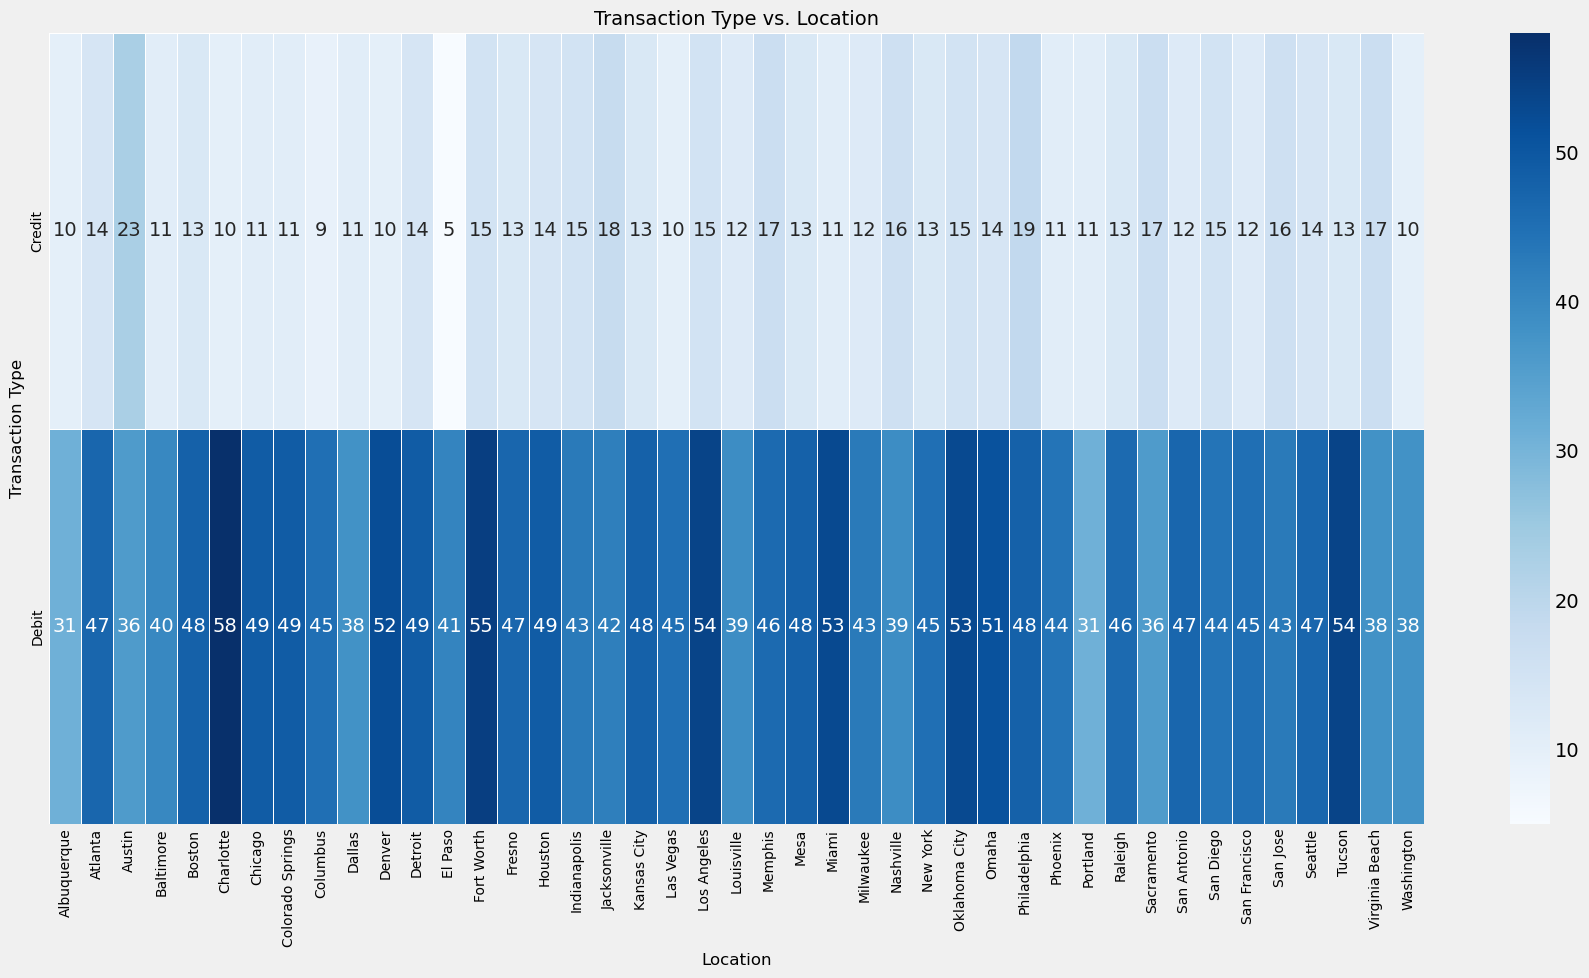

In [33]:
# Grouping data by TransactionType and Location
type_location = data.groupby(['TransactionType', 'Location']).size().unstack(fill_value=0)
print(f"Distribution of Transaction Type by {data['Location'].nunique()} Location:\n\n")
display(type_location)

# Heatmap
plt.figure(figsize=(18, 10))
sns.heatmap(type_location, cmap='Blues', annot=True, fmt='d', linewidths=0.5)
plt.title("Transaction Type vs. Location", fontsize=14)
plt.xlabel("Location", fontsize=12)
plt.ylabel("Transaction Type", fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Distribution of Channel by 4 Customer Occupation:



,Channel,CustomerOccupation,Count
0,ATM,Doctor,215
1,ATM,Engineer,193
2,ATM,Retired,203
3,ATM,Student,222
4,Branch,Doctor,219
5,Branch,Engineer,218
6,Branch,Retired,207
7,Branch,Student,224
8,Online,Doctor,197
9,Online,Engineer,214


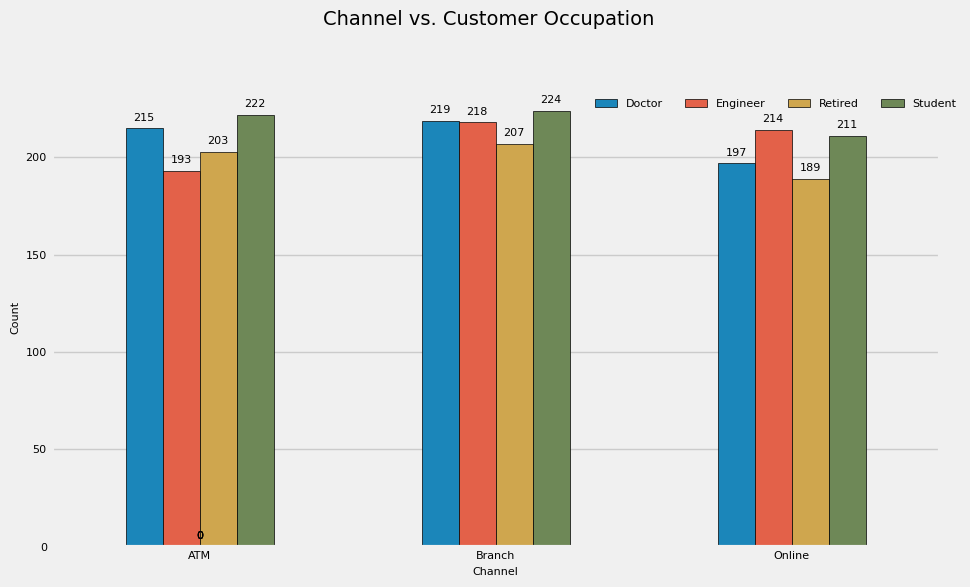

In [36]:
# Grouping data by Channel and Occupation
channel_occupation = data.groupby(['Channel', 'CustomerOccupation']).size().reset_index(name='Count')
print(f"Distribution of Channel by {data['CustomerOccupation'].nunique()} Customer Occupation:\n")
display(channel_occupation)

# Grouped bar chart
plt.figure(figsize=(10, 6))
plt.suptitle("Channel vs. Customer Occupation",fontsize=14)
ax = sns.barplot(data=channel_occupation, x='Channel', y='Count', hue='CustomerOccupation',width=0.5,edgecolor='black')

sns.move_legend(ax, "upper left",
    bbox_to_anchor=(.6, 1), ncol=4, title=None, frameon=False, fontsize=8
)

total = float(len(data["Channel"]) )
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 4,
            '{:1.0f}'.format((height)),
            ha="center",fontsize=8) 

plt.xlabel("Channel", fontsize=8)
plt.ylabel("Count", fontsize=8)
plt.xticks(rotation=0, fontsize=8)
plt.yticks(fontsize=8)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

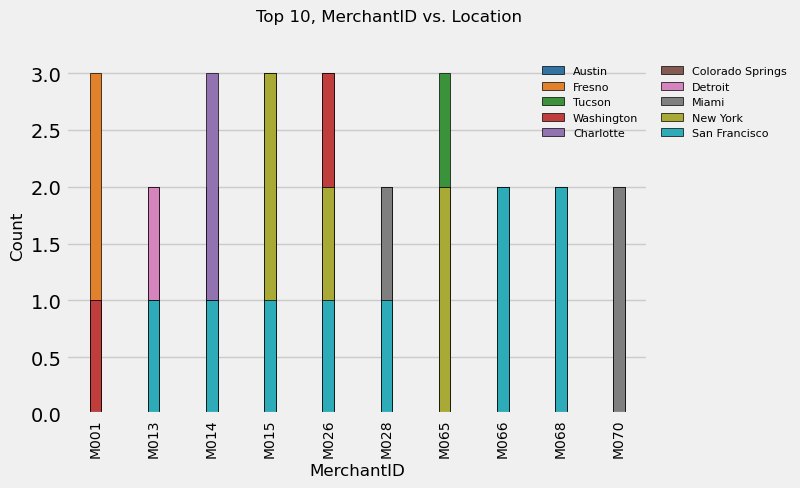

In [27]:
# Grouping data by MerchantID and Location
merchant_location = data.groupby(['MerchantID', 'Location']).size().reset_index(name='Count')

# Get top 10 MerchantID
top_10_merchants = merchant_location.groupby('MerchantID')['Count'].sum().sort_values(ascending=False).head(10).index

# Filter data for top 10 MerchantID
top_10_merchant_location = merchant_location[merchant_location['MerchantID'].isin(top_10_merchants)]

# Get top 10 locations
top_10_locations = top_10_merchant_location.groupby('Location')['Count'].sum().sort_values(ascending=False).head(10).index

# Filter data for top 10 locations
top_10_merchant_location = top_10_merchant_location[top_10_merchant_location['Location'].isin(top_10_locations)]

# Stacked bar chart
plt.figure(figsize=(8, 5))
plt.suptitle("Top 10, MerchantID vs. Location",fontsize=12)
ax=sns.barplot(data=top_10_merchant_location, x='MerchantID', y='Count', hue='Location', dodge=False,palette='tab10',width=0.2,edgecolor='black')
sns.move_legend(ax, "upper left",
    bbox_to_anchor=(.8, 1), ncol=2, title=None, frameon=False, fontsize=8
)
plt.xlabel("MerchantID", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.tight_layout()
plt.show()